# Homework 3: Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection

**Student Name:** Nimrod Kritmaler   
**Course:** Introduction to Data Science  
**Lecturer:** Dr. Uri Itai  
**Dataset:** NBA Games Data  

---

## Project Objective

The purpose of this project is to investigate the hidden structure and unusual observations in historical NBA game data using unsupervised learning methods.

Unlike supervised learning, the analysis is not guided by a predefined target variable. Instead, it examines whether the statistical profiles of NBA games contain meaningful clusters, redundant dimensions, local structures, or observations that differ substantially from typical games.

The analysis combines:

- Exploratory data analysis
- Principal Component Analysis
- Sample and feature clustering
- Multi-dimensional anomaly detection
- Comparison of competing methods
- Critical interpretation of the results and their limitations

Particular attention is given to the fact that clustering and anomaly detection are fundamentally ill-defined problems. Different algorithms may produce different results because they rely on different assumptions about distance, density, cluster geometry, and the meaning of abnormality. Therefore, the objective is not merely to produce clusters or anomaly labels, but to evaluate whether the results are stable, interpretable, and meaningful in the context of professional basketball.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

games_file_path = Path("data/games.csv")
games_df = pd.read_csv(games_file_path)

## 1. Dataset Selection 

The selected dataset is the `games.csv` file from the **NBA Games Data** collection. Each row represents a historical NBA game and contains information about the game date, season, participating teams, team-level performance, and final outcome.

The dataset satisfies all requirements specified in the assignment:

- It contains 26,651 rows, which is substantially more than the required 1,000 observations.
- It contains 21 columns, including 12 numerical basketball-performance features suitable for the unsupervised analysis.
- Most of the variables are stored numerically.
- It represents real-world professional basketball games.
- It does not contain a pre-labeled anomaly column.

The variable `HOME_TEAM_WINS` indicates whether the home team won the game. It is a game-outcome label rather than an anomaly label, so it does not violate the dataset requirements. However, it will not be used as an input to PCA, clustering, or anomaly-detection algorithms. It may be examined only after model fitting to help interpret the results.

**Where the dataset comes from**

The dataset was downloaded from [NBA Games Data on Kaggle](https://www.kaggle.com/datasets/nathanlauga/nba-games/data) and was published by Nathan Lauga. According to the dataset description, it was created using information obtained from the NBA statistics website. The complete Kaggle collection contains several related files, while this project uses `games.csv`.

**Why the dataset was collected**

The original information appears to come from the NBA's operational game-reporting and box-score systems, which document official game results and team-performance statistics. The Kaggle publisher also presents game-winner prediction as one possible analytical use of the dataset.

The data is observational and was not generated through a controlled experiment. Therefore, relationships identified during the analysis should not automatically be interpreted as causal effects.

**Who collected the data**

The underlying game information appears to have been recorded by the NBA as part of its official statistics system. Nathan Lauga published the assembled dataset on Kaggle. However, the precise extraction procedure, validation process, and division of responsibility between the original NBA system and the Kaggle publisher are not fully documented.

**Feature descriptions**

| Feature | Description |
|---|---|
| `GAME_DATE_EST` | The recorded date of the game |
| `GAME_ID` | A game identifier |
| `GAME_STATUS_TEXT` | The recorded status of the game |
| `HOME_TEAM_ID` | The identifier of the home team |
| `VISITOR_TEAM_ID` | The identifier of the visiting team |
| `SEASON` | The NBA season associated with the game |
| `TEAM_ID_home` | A repeated identifier for the home team |
| `PTS_home` | Points scored by the home team |
| `FG_PCT_home` | Field-goal percentage of the home team |
| `FT_PCT_home` | Free-throw percentage of the home team |
| `FG3_PCT_home` | Three-point percentage of the home team |
| `AST_home` | Number of assists recorded by the home team |
| `REB_home` | Number of rebounds recorded by the home team |
| `TEAM_ID_away` | A repeated identifier for the away team |
| `PTS_away` | Points scored by the away team |
| `FG_PCT_away` | Field-goal percentage of the away team |
| `FT_PCT_away` | Free-throw percentage of the away team |
| `FG3_PCT_away` | Three-point percentage of the away team |
| `AST_away` | Number of assists recorded by the away team |
| `REB_away` | Number of rebounds recorded by the away team |
| `HOME_TEAM_WINS` | A binary indicator equal to 1 when the home team won and 0 otherwise |

The main feature matrix will contain the 12 home-team and away-team performance variables: points, field-goal percentage, free-throw percentage, three-point percentage, assists, and rebounds.

Although the game and team identifiers are stored as integers, they represent identifiers rather than measurable quantities. They will not be included in distance calculations, PCA, clustering, or anomaly detection.

**Possible limitations and biases**

- The dataset does not include information about injuries, player availability, rest days, travel, coaching decisions, or game importance.
- Basketball strategy, pace, rules, and three-point shooting changed across the seasons represented in the dataset. A game may appear unusual relative to the complete dataset while being typical for its own season.
- Points, assists, and rebounds are raw totals that may be affected by game pace and overtime.
- Shooting percentages are provided without the corresponding numbers of attempts. An extreme percentage may therefore be based on a small number of shots.
- Previous analysis found 99 games in which all 12 performance variables are missing. These observations are concentrated in part of the 2003 season, suggesting structured rather than random missingness.
- Twenty-nine game identifiers occur more than once. Most corresponding records are nearly identical, but two duplicated identifiers contain meaningful conflicts.
- The exact extraction method, validation rules, version history, and update schedule are not fully documented.
- The data represents NBA games and should not automatically be generalized to other basketball leagues.
- The separation between home-team and away-team statistics may create redundancy between related features.

These limitations are especially important for anomaly detection. A statistically unusual game is not necessarily erroneous. It may represent a legitimate exceptional performance, an effect of the historical period, an overtime game, or an unstable shooting percentage based on very few attempts. Consequently, anomaly labels must be interpreted as signals for further investigation rather than proof of incorrect data.

## 2. Exploratory Data Analysis 

The purpose of this section is to understand the structure, quality, distributions, and relationships of the variables before applying dimensionality-reduction, clustering, or anomaly-detection methods.

The exploratory analysis is performed on the original dataset. Data-cleaning decisions for the unsupervised models will be made only after the relevant data-quality issues have been examined.

### Structural Analysis

The structural analysis examines the number of rows and columns, data types, missing values, statistical summaries, and correlations between the main numerical features.

In [2]:
statistical_columns = [
    "PTS_home",
    "FG_PCT_home",
    "FT_PCT_home",
    "FG3_PCT_home",
    "AST_home",
    "REB_home",
    "PTS_away",
    "FG_PCT_away",
    "FT_PCT_away",
    "FG3_PCT_away",
    "AST_away",
    "REB_away"
]

In [3]:
column_summary_df = pd.DataFrame({
    "Data Type": games_df.dtypes.astype(str),
    "Non-Null Values": games_df.notna().sum(),
    "Missing Values": games_df.isna().sum(),
    "Unique Values": games_df.nunique(dropna=False)
})

print("DATASET DIMENSIONS")
print("-" * 50)
print(f"Number of rows: {games_df.shape[0]:,}")
print(f"Number of columns: {games_df.shape[1]}")

print("\nCOLUMN SUMMARY")
display(column_summary_df)

DATASET DIMENSIONS
--------------------------------------------------
Number of rows: 26,651
Number of columns: 21

COLUMN SUMMARY


,Data Type,Non-Null Values,Missing Values,Unique Values
GAME_DATE_EST,str,26651,0,4304
GAME_ID,int64,26651,0,26622
GAME_STATUS_TEXT,str,26651,0,1
HOME_TEAM_ID,int64,26651,0,30
VISITOR_TEAM_ID,int64,26651,0,30
SEASON,int64,26651,0,20
TEAM_ID_home,int64,26651,0,30
PTS_home,float64,26552,99,101
FG_PCT_home,float64,26552,99,405
FT_PCT_home,float64,26552,99,411


In [4]:
missing_rows = games_df[
    games_df[statistical_columns].isna().any(axis=1)
]

print(f"Rows with missing statistical values: {len(missing_rows):,}")
print(f"Percentage of rows: {len(missing_rows) / len(games_df) * 100:.2f}%")

print("\nNumber of missing values in each statistical feature:")
display(games_df[statistical_columns].isna().sum().to_frame("Missing Values"))

print("Seasons containing missing statistical values:")
display(missing_rows["SEASON"].value_counts().sort_index())

print("Date range of the missing observations:")
print(missing_rows["GAME_DATE_EST"].min())
print(missing_rows["GAME_DATE_EST"].max())

Rows with missing statistical values: 99
Percentage of rows: 0.37%

Number of missing values in each statistical feature:


,Missing Values
PTS_home,99
FG_PCT_home,99
FT_PCT_home,99
FG3_PCT_home,99
AST_home,99
REB_home,99
PTS_away,99
FG_PCT_away,99
FT_PCT_away,99
FG3_PCT_away,99


Seasons containing missing statistical values:


SEASON
2003    99
Name: count, dtype: int64

Date range of the missing observations:
2003-10-07
2003-10-24


In [5]:
statistical_summary_df = (
    games_df[statistical_columns]
    .describe()
    .T
)

display(statistical_summary_df)

,count,mean,std,min,25%,50%,75%,max
PTS_home,26552.0,103.455898,13.283370,36.000,94.000,103.000,112.000,168.000
FG_PCT_home,26552.0,0.460735,0.056676,0.250,0.422,0.460,0.500,0.684
FT_PCT_home,26552.0,0.760377,0.100677,0.143,0.697,0.765,0.833,1.000
FG3_PCT_home,26552.0,0.356023,0.111164,0.000,0.286,0.357,0.429,1.000
AST_home,26552.0,22.823441,5.193308,6.000,19.000,23.000,26.000,50.000
REB_home,26552.0,43.374284,6.625769,15.000,39.000,43.000,48.000,72.000
PTS_away,26552.0,100.639876,13.435868,33.000,91.000,100.000,110.000,168.000
FG_PCT_away,26552.0,0.449732,0.055551,0.244,0.412,0.449,0.487,0.687
FT_PCT_away,26552.0,0.758816,0.103429,0.143,0.692,0.765,0.833,1.000
FG3_PCT_away,26552.0,0.349489,0.109441,0.000,0.278,0.350,0.419,1.000


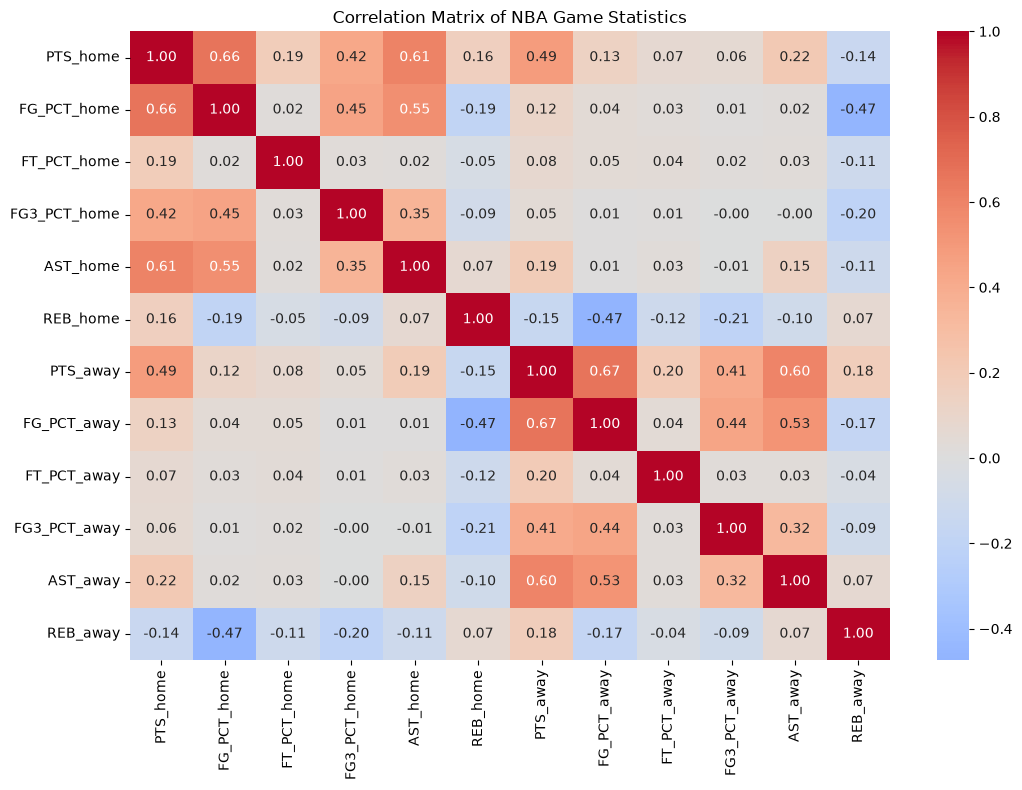

In [6]:
correlation_matrix = games_df[statistical_columns].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of NBA Game Statistics")
plt.tight_layout()
plt.show()

#### Structural Analysis Findings

The dataset contains 26,651 rows and 21 columns. The 12 selected basketball-performance variables contain 26,552 valid observations each.

The remaining variables describe dates, seasons, identifiers, game status, and the game outcome. Although the game and team identifiers are stored as integers, they represent categorical identifiers rather than measurable quantities. They will therefore be excluded from PCA, clustering, and anomaly-detection calculations. In addition, `GAME_STATUS_TEXT` contains only one unique value and provides no analytical variation.

A total of 99 rows, representing approximately 0.37% of the dataset, contain missing values in the selected performance variables. All 12 variables are missing in the same observations. These games belong to the 2003 season and were recorded between October 7 and October 24, 2003. Their concentration within a specific period suggests a systematic historical coverage problem rather than independent random missingness.

Because these rows contain no recorded values for any selected performance feature, replacing them with means or medians would create artificial game profiles. They will therefore be excluded from analyses that require these variables.

The statistical summary shows that home teams scored an average of approximately 103.46 points, compared with 100.64 points for away teams. The corresponding medians are 103 and 100 points. Home teams also have slightly higher average field-goal percentage, three-point percentage, assists, and rebounds. These differences are descriptive and do not establish a causal effect of playing at home.

The correlation matrix reveals several notable relationships:

- Home-team points and home-team field-goal percentage have a correlation of approximately 0.66.
- Home-team points and home-team assists have a correlation of approximately 0.61.
- Away-team points and away-team field-goal percentage have a correlation of approximately 0.67.
- Away-team points and away-team assists have a correlation of approximately 0.60.
- Home-team and away-team points have a moderate positive correlation of approximately 0.49.

These relationships indicate partial redundancy among scoring, shooting efficiency, and assists. They also suggest that some variation is shared by both teams within a game, which supports the later use of PCA to summarize correlated features.

### Distribution Analysis

The following analysis examines the distribution of each major performance feature using a histogram, boxplot, skewness, and kurtosis.

Skewness describes the asymmetry of a distribution. A value near zero indicates approximate symmetry, a positive value indicates a longer right tail, and a negative value indicates a longer left tail.

The kurtosis values calculated by pandas are excess-kurtosis values. A value near zero is similar to the kurtosis of a normal distribution, while a positive value indicates heavier tails and a negative value indicates lighter tails.

In [7]:
distribution_shape_df = pd.DataFrame({
    "Skewness": games_df[statistical_columns].skew(),
    "Kurtosis": games_df[statistical_columns].kurtosis()
}).round(3)

display(distribution_shape_df)

,Skewness,Kurtosis
PTS_home,0.173,0.101
FG_PCT_home,0.096,-0.048
FT_PCT_home,-0.380,0.432
FG3_PCT_home,0.060,0.486
AST_home,0.248,0.068
REB_home,0.184,0.083
PTS_away,0.187,0.080
FG_PCT_away,0.082,0.016
FT_PCT_away,-0.372,0.404
FG3_PCT_away,0.088,0.614


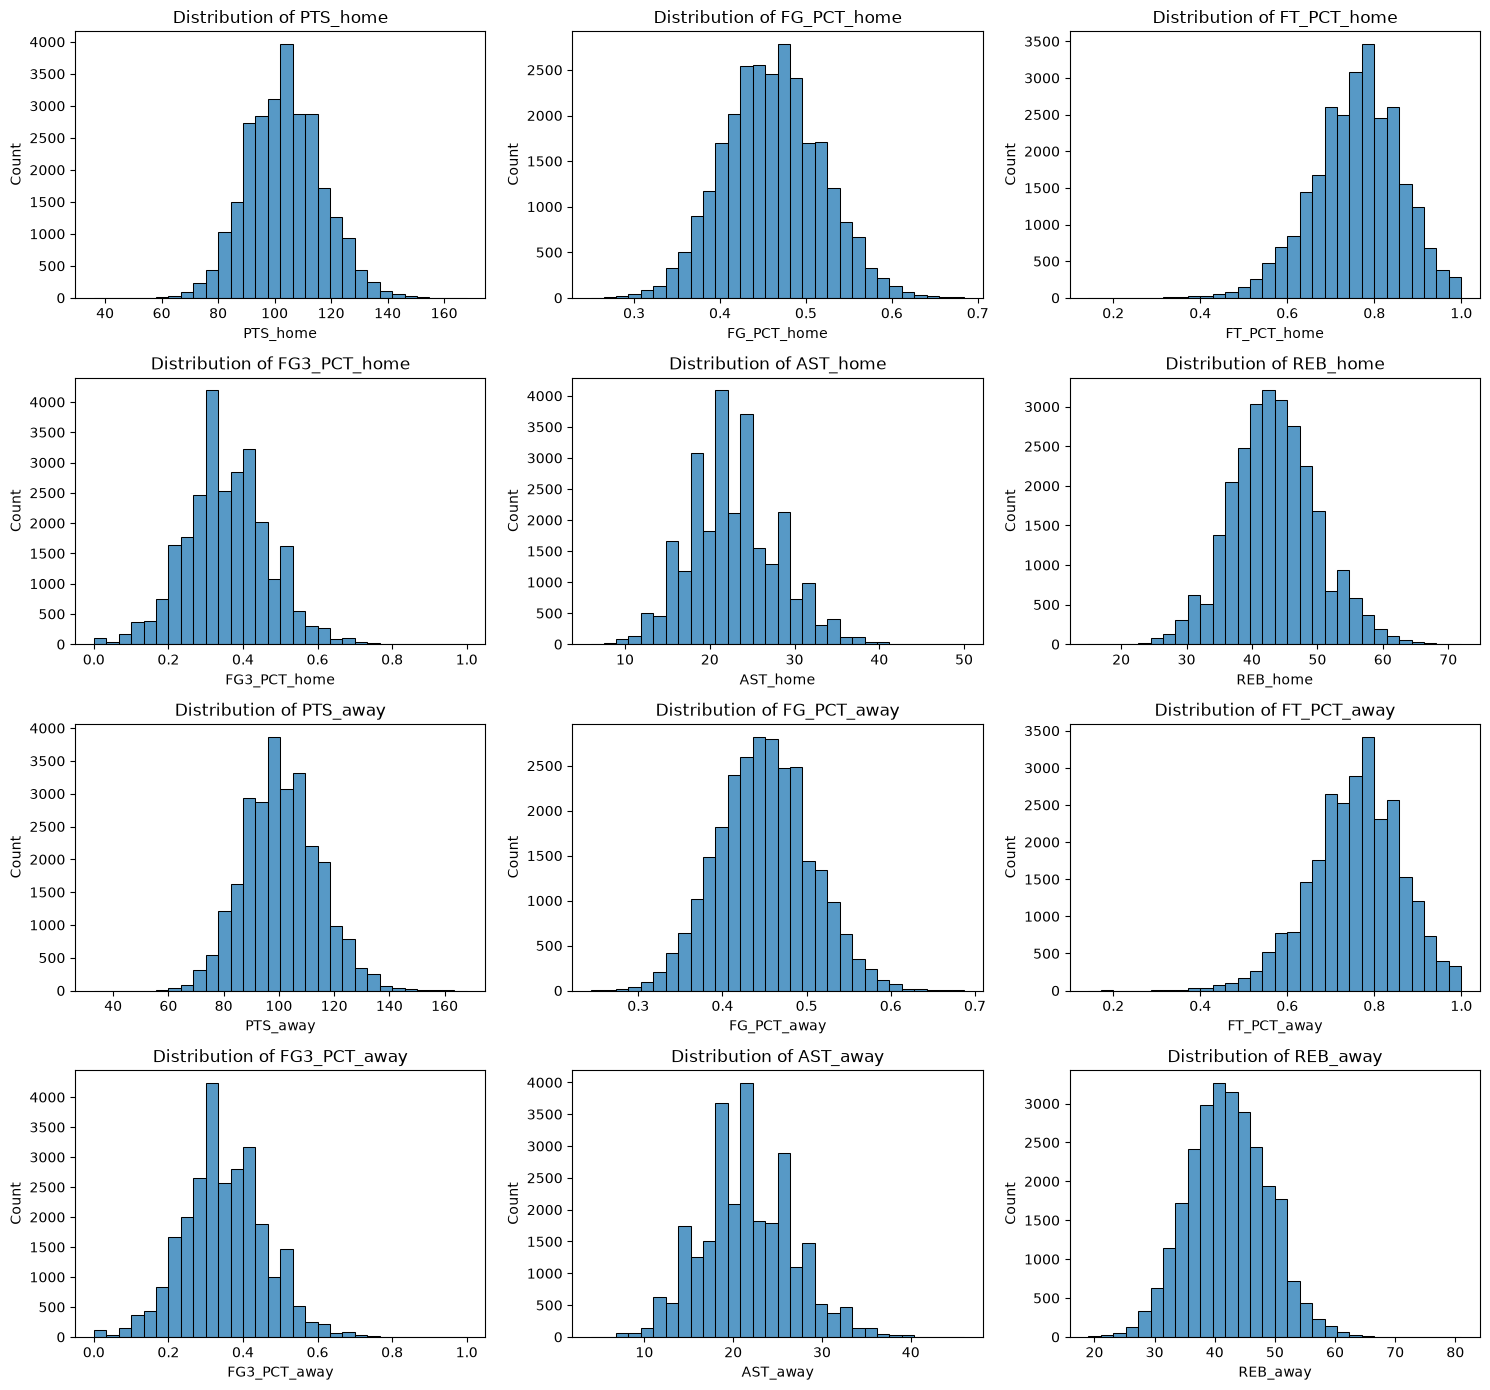

In [8]:
figure, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for axis, column_name in zip(axes, statistical_columns):
    sns.histplot(
        data=games_df,
        x=column_name,
        bins=30,
        ax=axis
    )
    axis.set_title(f"Distribution of {column_name}")

plt.tight_layout()
plt.show()

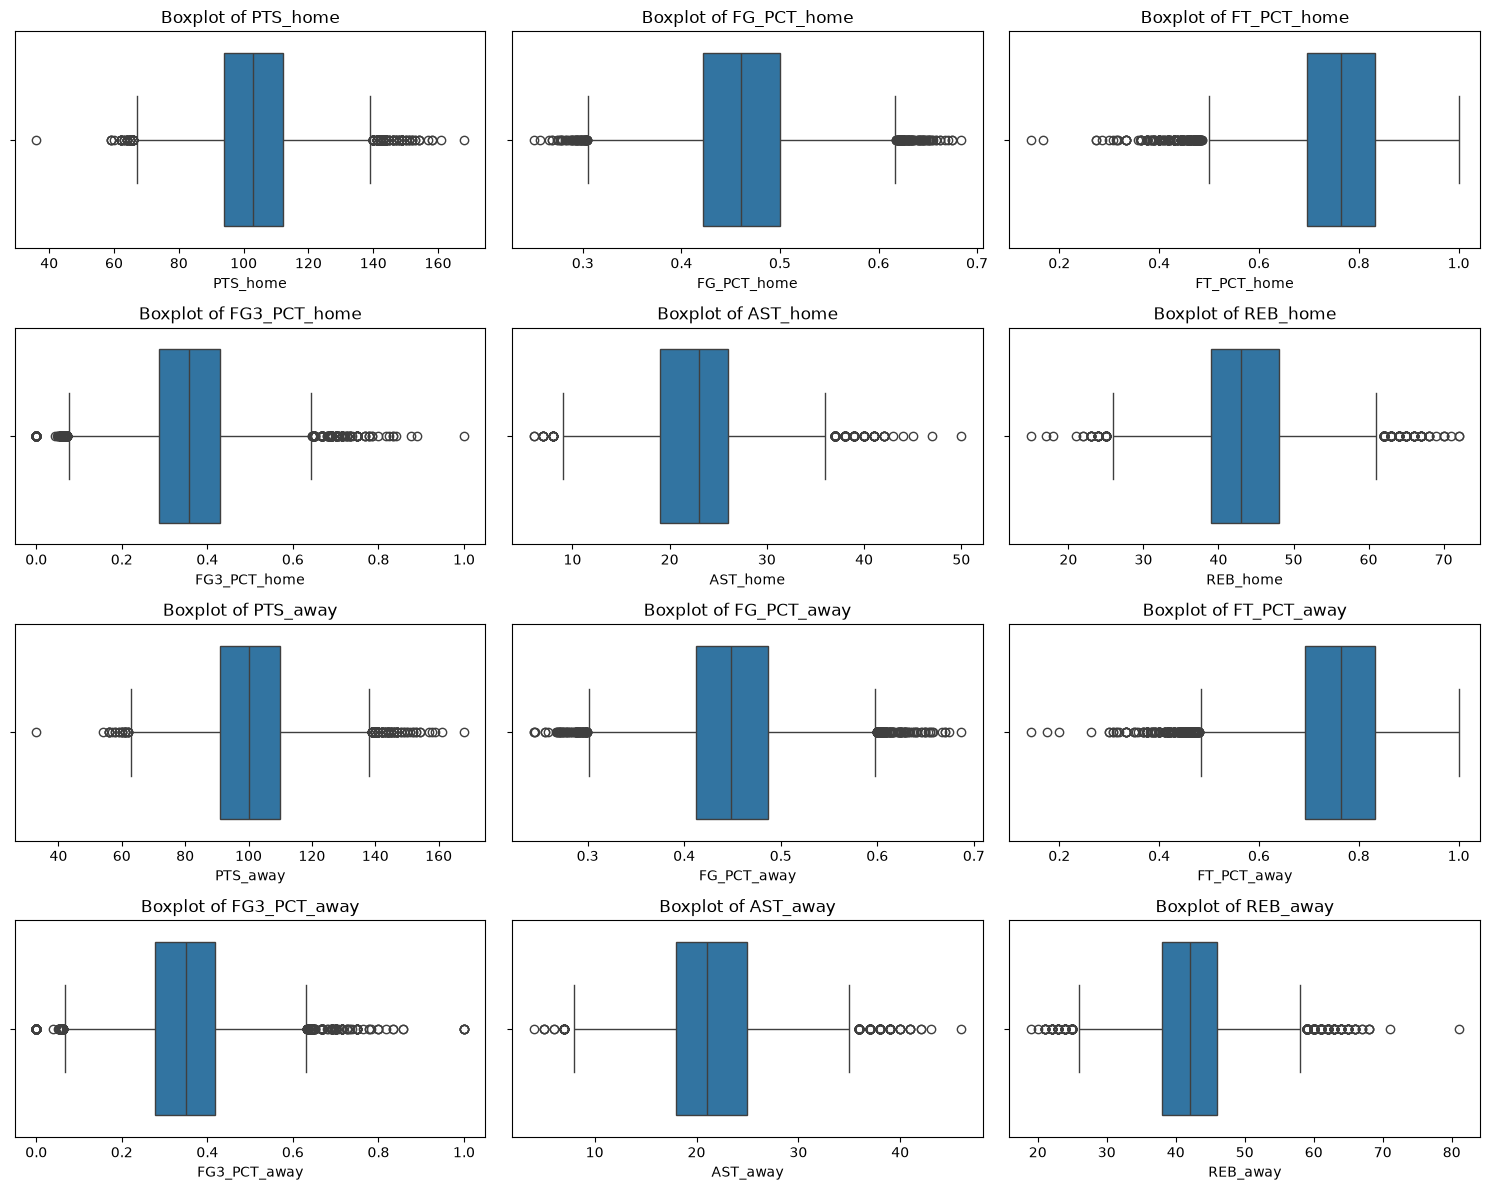

In [9]:
figure, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for axis, column_name in zip(axes, statistical_columns):
    sns.boxplot(
        data=games_df,
        x=column_name,
        ax=axis
    )
    axis.set_title(f"Boxplot of {column_name}")

plt.tight_layout()
plt.show()

#### Distribution Analysis Findings
The histograms show that most of the performance variables have approximately unimodal and symmetric central distributions. This observation is supported by the skewness values, whose absolute values are below 0.4 for all 12 features.

The point distributions are approximately bell-shaped, with mild positive skewness of 0.173 for home teams and 0.187 for away teams. Assists and rebounds also have small positive skewness values. Their histograms contain visible steps because these variables are discrete integer counts rather than continuous measurements.

Field-goal percentage is close to symmetric for both home and away teams. Its skewness values are 0.096 and 0.082, while its kurtosis values are close to zero. The central shape of these distributions is therefore reasonably similar to a normal distribution, although the percentages remain bounded between zero and one.

Free-throw percentage has the most noticeable negative skewness: -0.380 for home teams and -0.372 for away teams. The histograms show that most games are concentrated around relatively high free-throw percentages, while a smaller number of games form a longer tail toward poor free-throw performance.

Three-point percentage is approximately symmetric near its center, but its distributions have the highest kurtosis values: 0.486 for home teams and 0.614 for away teams. The histograms and boxplots show observations extending toward both zero and one. These heavier tails may partly result from games in which a shooting percentage was calculated from a relatively small number of attempts.

Most kurtosis values are close to zero, so the distributions do not exhibit severe overall tail heaviness. Nevertheless, the boxplots identify extreme observations in every feature. The large number of observations in the dataset means that even a relatively small proportion of unusual games can produce many visible points beyond the boxplot whiskers.

These extreme observations should not be removed automatically. They may represent legitimate exceptional performances, overtime games, unusual game pace, differences between historical eras, or measurement and data-quality issues. Their meaning will be examined more carefully in the outlier and multi-dimensional anomaly analyses.

### Outlier Exploration

The following analysis examines heavy tails, extreme values, possible noise, measurement artifacts, and potential data-entry problems.

The interquartile-range rule is first used as a simple feature-wise method for describing extreme observations. A value is classified as extreme when it falls below $Q_1 - 1.5 \times IQR$ or above $Q_3 + 1.5 \times IQR$.

This exploratory rule does not determine whether an entire game is a multi-dimensional anomaly. It only identifies observations that are extreme in individual features. The required multi-dimensional anomaly-detection methods will be applied later.

In [10]:
outlier_summary = []

for column_name in statistical_columns:
    first_quartile = games_df[column_name].quantile(0.25)
    third_quartile = games_df[column_name].quantile(0.75)
    interquartile_range = third_quartile - first_quartile

    lower_bound = first_quartile - 1.5 * interquartile_range
    upper_bound = third_quartile + 1.5 * interquartile_range

    outlier_count = (
        (games_df[column_name] < lower_bound) |
        (games_df[column_name] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": column_name,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": (
            outlier_count / games_df[column_name].count() * 100
        )
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df.round(3))

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,PTS_home,67.000,139.000,207,0.780
1,FG_PCT_home,0.305,0.617,153,0.576
2,FT_PCT_home,0.493,1.037,209,0.787
3,FG3_PCT_home,0.071,0.644,381,1.435
4,AST_home,8.500,36.500,215,0.810
5,REB_home,25.500,61.500,201,0.757
6,PTS_away,62.500,138.500,134,0.505
7,FG_PCT_away,0.300,0.600,197,0.742
8,FT_PCT_away,0.481,1.044,250,0.942
9,FG3_PCT_away,0.067,0.630,359,1.352


In [11]:
percentage_columns = [
    "FG_PCT_home",
    "FT_PCT_home",
    "FG3_PCT_home",
    "FG_PCT_away",
    "FT_PCT_away",
    "FG3_PCT_away"
]

count_columns = [
    "PTS_home",
    "AST_home",
    "REB_home",
    "PTS_away",
    "AST_away",
    "REB_away"
]

invalid_percentage_counts = (
    (games_df[percentage_columns] < 0) |
    (games_df[percentage_columns] > 1)
).sum()

negative_value_counts = (
    games_df[count_columns] < 0
).sum()

print("Invalid percentage values:")
display(invalid_percentage_counts.to_frame("Invalid Values"))

print("Negative count values:")
display(negative_value_counts.to_frame("Negative Values"))

Invalid percentage values:


,Invalid Values
FG_PCT_home,0
FT_PCT_home,0
FG3_PCT_home,0
FG_PCT_away,0
FT_PCT_away,0
FG3_PCT_away,0


Negative count values:


,Negative Values
PTS_home,0
AST_home,0
REB_home,0
PTS_away,0
AST_away,0
REB_away,0


In [12]:
boundary_value_summary = pd.DataFrame({
    "Zero Values": (games_df[percentage_columns] == 0).sum(),
    "One Values": (games_df[percentage_columns] == 1).sum()
})

repeated_game_rows = games_df[
    games_df["GAME_ID"].duplicated(keep=False)
]

display(boundary_value_summary)

print(f"Full-row duplicates: {games_df.duplicated().sum()}")
print(f"Repeated GAME_ID values: {repeated_game_rows['GAME_ID'].nunique()}")
print(f"Rows with repeated GAME_ID values: {len(repeated_game_rows)}")

,Zero Values,One Values
FG_PCT_home,0,0
FT_PCT_home,0,281
FG3_PCT_home,106,1
FG_PCT_away,0,0
FT_PCT_away,0,324
FG3_PCT_away,118,5


Full-row duplicates: 0
Repeated GAME_ID values: 29
Rows with repeated GAME_ID values: 58


#### Outlier Exploration Findings

The IQR analysis identifies feature-wise extreme values in all 12 performance variables. However, the proportion of values outside the IQR boundaries is relatively small, ranging from approximately 0.50% to 1.44% per feature.

The largest outlier percentage is observed for home-team three-point percentage, at approximately 1.44%, followed by away-team three-point percentage at approximately 1.35%. Away-team rebounds also have a relatively high outlier percentage of approximately 1.31%. Away-team points have the lowest percentage, at approximately 0.50%.

The skewness and kurtosis results do not indicate severely heavy-tailed distributions. Nevertheless, the three-point percentage variables have the highest kurtosis values and relatively large numbers of IQR outliers. This agrees with the long tails visible in their histograms and boxplots.

The statistical summary contains several extreme observations. Home-team points range from 36 to 168, while away-team points range from 33 to 168. Home-team rebounds range from 15 to 72, and away-team rebounds range from 19 to 81. Assists range from 6 to 50 for home teams and from 4 to 46 for away teams. These values are unusual, but they remain possible in professional basketball, particularly in games affected by overtime, unusually high or low pace, or exceptional team performance.

No negative values were found in the point, assist, or rebound variables. In addition, all recorded shooting percentages fall within the valid range from zero to one. The range checks therefore provide no evidence of clearly impossible numerical values.

The percentage variables contain several boundary values. Home and away teams recorded zero three-point percentage in 106 and 118 games, respectively. These values may indicate that a team missed all of its three-point attempts. Values of one represent 100% shooting and occur mainly in the free-throw variables, with 281 home-team and 324 away-team observations. A small number of three-point percentages are also equal to one.

These boundary percentages are not necessarily data-entry errors. However, the dataset does not include the number of shooting attempts, so a percentage of zero or one may be based on very few attempts. This missing denominator limits the ability to distinguish exceptional shooting from an unstable percentage based on a small sample.

The histograms of points, assists, and rebounds contain visible steps because these statistics are recorded as integer counts. Shooting percentages are also rounded in the dataset. These properties are measurement artifacts that can create repeated values and visible peaks without indicating genuine subgroups.

The dataset contains no exact full-row duplicates, but 29 `GAME_ID` values appear more than once, affecting 58 rows. Because the corresponding rows are not exactly identical, they should not be removed automatically without examining their differences. The repeated identifiers may reflect rounding differences, multiple record versions, or data-extraction inconsistencies.

The 99 rows with simultaneously missing performance statistics represent the clearest data-quality concern. Their concentration within a short period of the 2003 season suggests a systematic coverage issue rather than random measurement noise.

Overall, the exploratory analysis distinguishes three possible sources of extreme observations:

- Legitimate unusual basketball performances
- Measurement effects caused by discrete counts, rounded percentages, or missing shooting-attempt information
- Data-quality problems such as structured missingness and repeated game identifiers

The IQR rule examines each feature independently and cannot determine whether an entire game has an unusual multi-dimensional profile. The required Z-score, Isolation Forest, and Local Outlier Factor methods will later provide complementary definitions of abnormality.

## 3. Dimensionality Reduction

### 3.1 Principal Component Analysis (PCA)

Before applying PCA, the analytical dataset must contain one row per game and complete values for all selected performance features.

The 99 observations with missing values in all 12 performance variables are removed because PCA cannot operate directly on missing values. Imputing complete game profiles would create artificial observations.

Repeated `GAME_ID` values are reduced to one row per game by retaining the first occurrence. This prevents repeated games from receiving additional weight in the analysis. Because the repeated rows are not completely identical, this decision will be treated as a data-quality limitation.

The final PCA feature matrix contains the 12 home-team and away-team performance variables defined during the exploratory analysis. Identifiers, dates, season, game status, and `HOME_TEAM_WINS` are excluded.

The features must be standardized before PCA. Points, assists, and rebounds are measured as counts, while shooting percentages range from zero to one. Without standardization, variables with larger numerical scales would dominate the principal components.

In [13]:
complete_games_df = games_df.dropna(
    subset=statistical_columns
).copy()

analysis_df = complete_games_df.drop_duplicates(
    subset="GAME_ID",
    keep="first"
).copy()

X = analysis_df[statistical_columns]

missing_rows_removed = len(games_df) - len(complete_games_df)
repeated_rows_removed = len(complete_games_df) - len(analysis_df)

print(f"Original number of rows: {len(games_df):,}")
print(f"Rows removed because of missing values: {missing_rows_removed:,}")
print(f"Repeated game records removed: {repeated_rows_removed:,}")
print(f"Final number of rows: {len(analysis_df):,}")
print(f"Number of PCA features: {X.shape[1]}")

Original number of rows: 26,651
Rows removed because of missing values: 99
Repeated game records removed: 29
Final number of rows: 26,523
Number of PCA features: 12


#### Mathematical Intuition

Principal Component Analysis transforms the original correlated features into a new set of mutually orthogonal variables called principal components.

Before PCA is applied, each original feature is standardized:

$$
z_j = \frac{x_j-\mu_j}{\sigma_j}
$$

where $x_j$ is the original value, $\mu_j$ is the feature mean, and $\sigma_j$ is its standard deviation.

Each principal component is then calculated as a linear combination of the standardized features:

$$
PC_k = w_{k1}z_1 + w_{k2}z_2 + \cdots + w_{kp}z_p
$$

The coefficients $w_{k1},\ldots,w_{kp}$ determine the direction of component $k$ and describe the contribution of each standardized feature to that component.

The first principal component is the direction that captures the largest possible variance in the data. Each following component captures the largest remaining variance while remaining orthogonal to the preceding components.

PCA can reduce dimensionality when several original features contain overlapping information. However, it is a linear method and may fail to preserve non-linear or highly local structures. Its components may also be less directly interpretable than the original basketball variables.

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca_scores = pca.fit_transform(X_scaled)

In [15]:
component_names = [
    f"PC{component_number}"
    for component_number in range(1, len(statistical_columns) + 1)
]

explained_variance_df = pd.DataFrame({
    "Principal Component": component_names,
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance":
        pca.explained_variance_ratio_.cumsum()
})

display(explained_variance_df.round(3))

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.258,0.258
1,PC2,0.192,0.450
2,PC3,0.115,0.566
3,PC4,0.087,0.652
4,PC5,0.084,0.736
5,PC6,0.069,0.805
6,PC7,0.056,0.862
7,PC8,0.050,0.912
8,PC9,0.041,0.952
9,PC10,0.031,0.983


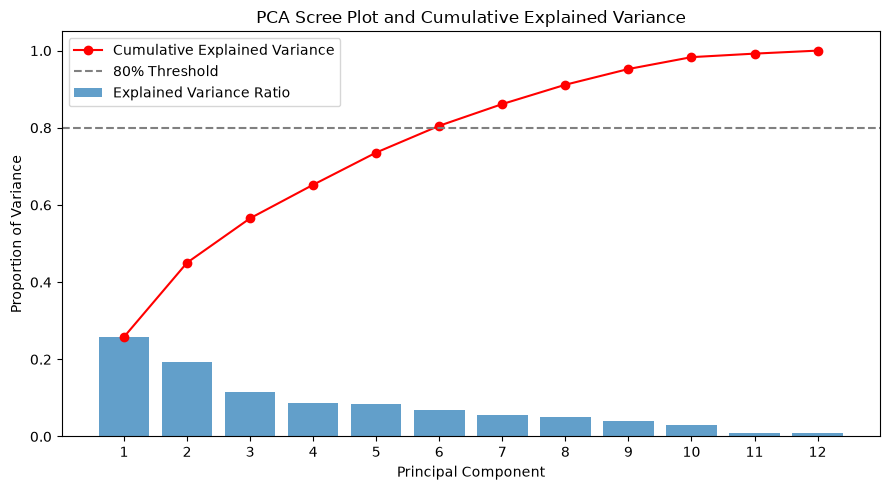

In [16]:
component_numbers = range(1, len(statistical_columns) + 1)

plt.figure(figsize=(9, 5))

plt.bar(
    component_numbers,
    pca.explained_variance_ratio_,
    alpha=0.7,
    label="Explained Variance Ratio"
)

plt.plot(
    component_numbers,
    pca.explained_variance_ratio_.cumsum(),
    marker="o",
    color="red",
    label="Cumulative Explained Variance"
)

plt.axhline(
    0.80,
    color="gray",
    linestyle="--",
    label="80% Threshold"
)

plt.xticks(component_numbers)
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance")
plt.title("PCA Scree Plot and Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
pca_loadings_df = pd.DataFrame(
    pca.components_.T,
    index=statistical_columns,
    columns=component_names
)

display(pca_loadings_df[["PC1", "PC2", "PC3"]].round(3))

,PC1,PC2,PC3
PTS_home,0.425,-0.283,0.286
FG_PCT_home,0.360,-0.391,-0.198
FT_PCT_home,0.094,-0.022,-0.065
FG3_PCT_home,0.252,-0.322,-0.114
AST_home,0.325,-0.329,0.225
REB_home,-0.160,-0.220,0.554
PTS_away,0.414,0.310,0.281
FG_PCT_away,0.351,0.398,-0.200
FT_PCT_away,0.094,0.054,-0.041
FG3_PCT_away,0.241,0.314,-0.138


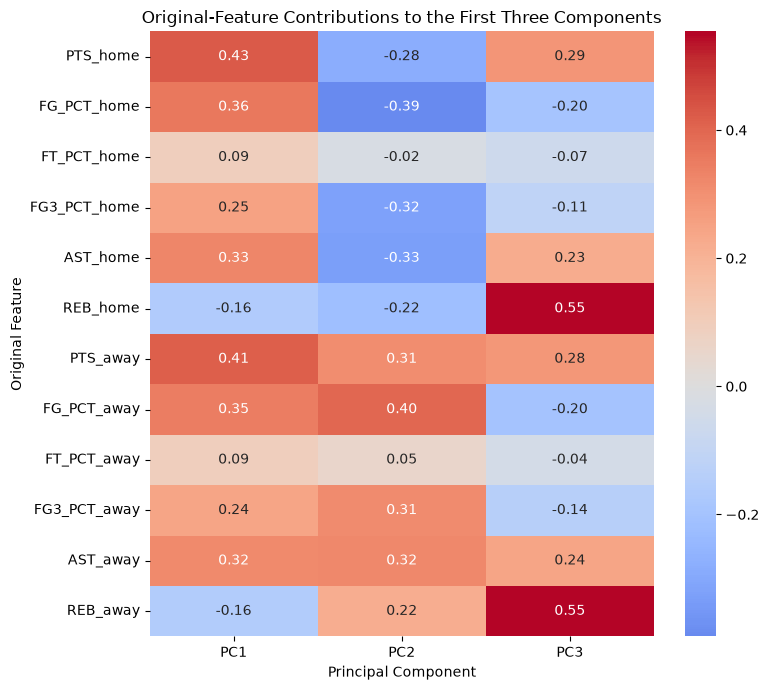

In [18]:
plt.figure(figsize=(8, 7))

sns.heatmap(
    pca_loadings_df[["PC1", "PC2", "PC3"]],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Original-Feature Contributions to the First Three Components")
plt.xlabel("Principal Component")
plt.ylabel("Original Feature")
plt.tight_layout()
plt.show()

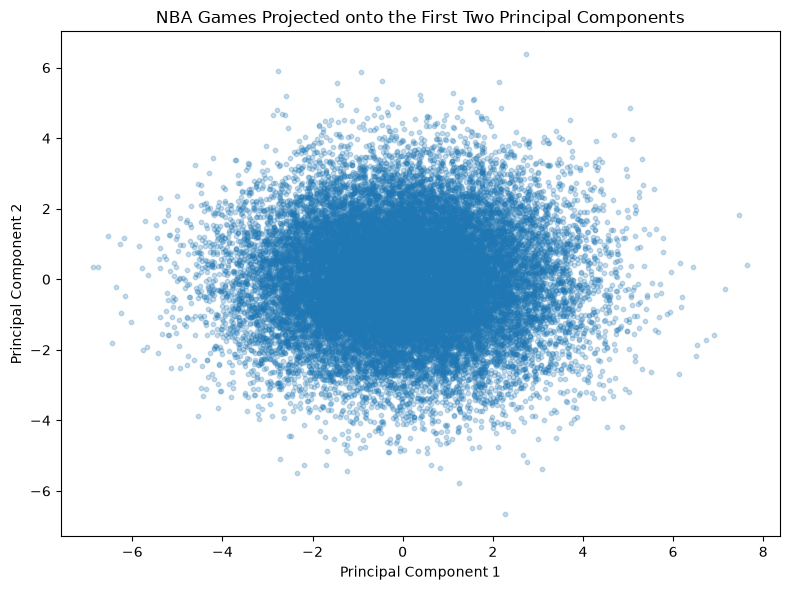

In [19]:
pca_projection_df = pd.DataFrame(
    pca_scores[:, :3],
    columns=["PC1", "PC2", "PC3"],
    index=analysis_df.index
)

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_projection_df["PC1"],
    pca_projection_df["PC2"],
    s=10,
    alpha=0.25
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("NBA Games Projected onto the First Two Principal Components")
plt.tight_layout()
plt.show()

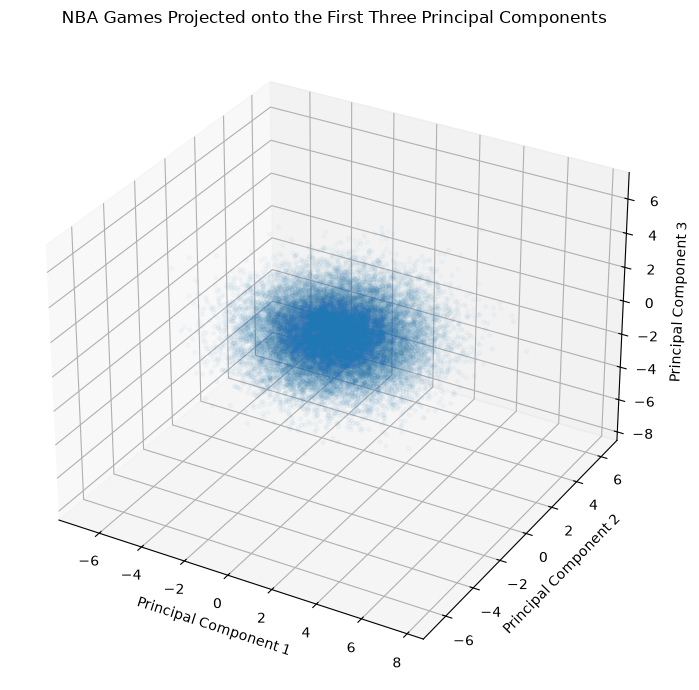

In [20]:
figure = plt.figure(figsize=(9, 7))
axis = figure.add_subplot(111, projection="3d")

axis.scatter(
    pca_projection_df["PC1"],
    pca_projection_df["PC2"],
    pca_projection_df["PC3"],
    s=8,
    alpha=0.2
)

axis.set_xlabel("Principal Component 1")
axis.set_ylabel("Principal Component 2")
axis.set_zlabel("Principal Component 3")
axis.set_title(
    "NBA Games Projected onto the First Three Principal Components"
)

plt.tight_layout()
plt.show()

#### PCA Results and Discussion

**Explained variance and number of components**

The first principal component explains approximately 25.8% of the total standardized variance, while the second and third components explain approximately 19.2% and 11.5%, respectively.

Together, the first two components explain approximately 45.0% of the variance, and the first three explain approximately 56.6%. The cumulative explained variance reaches approximately 73.6% with five components, 80.5% with six components, and 91.2% with eight components.

The number of components considered adequate therefore depends on the purpose of the analysis. Six components provide a reasonable compact representation by retaining approximately 80% of the variance while reducing the number of dimensions by half. If preserving at least 90% of the variance is preferred, eight components are required.

**Information loss**

Reducing the data to two dimensions retains approximately 45.0% of the total variance and loses approximately 55.0%. A three-dimensional representation retains approximately 56.6% and loses approximately 43.4%.

The 2D and 3D projections are therefore useful for visualization, but they should not be treated as complete representations of the original 12-dimensional data. By comparison, retaining six components loses approximately 19.5% of the variance, while retaining eight components loses approximately 8.8%.

Variance loss does not necessarily correspond directly to loss of anomaly information. An unusual observation may differ from the rest of the dataset along a low-variance direction. For that reason, the later anomaly-detection analysis should not rely exclusively on the first two or three components.

**Effect of correlated variables**

The exploratory analysis identified positive correlations between points, field-goal percentage, and assists for both home and away teams. These relationships cause the variables to contribute together to the leading principal components.

The moderate correlation between home-team and away-team points also suggests that some components capture shared game conditions, such as pace or overtime. The negative relationships between shooting efficiency and opposing-team rebounds represent another form of overlapping information.

PCA uses these dependencies to replace correlated original variables with orthogonal components. However, the fact that six components are required to explain approximately 80% of the variance shows that the dataset contains only moderate redundancy. The 12 original features cannot be represented accurately by only one or two dimensions.

**Interpretation of the major components**

The sign of a PCA component is arbitrary. Multiplying all coefficients of a component by negative one would produce an equivalent component. Therefore, the interpretation depends on the relative directions and magnitudes of the coefficients rather than on the sign alone.

`PC1` has its largest positive coefficients for home-team points, away-team points, field-goal percentages, and assists. The coefficients for the corresponding home and away variables point in the same direction. This component can therefore be interpreted as a general offensive-performance or high-scoring-game dimension. Games with a high `PC1` score tend to combine higher scoring, shooting efficiency, and ball movement for both teams.

`PC2` contrasts home-team and away-team performance. Away-team points, field-goal percentage, three-point percentage, and assists have positive coefficients, while the corresponding home-team variables have negative coefficients. A high `PC2` score therefore represents stronger away-team offensive performance relative to home-team performance, while a low score represents the opposite pattern.

`PC3` is dominated by home-team and away-team rebounds, with coefficients of approximately 0.55 for both variables. It also has positive contributions from points and assists and negative contributions from shooting percentages. This component may represent games with high rebounding and possession volume, potentially associated with more missed shots or a faster game environment.

Free-throw percentages have relatively small coefficients in the first three components. This indicates that they contain information that is not strongly represented by the leading offensive and rebounding dimensions and is captured more strongly by later components.

**Global and local structure**

PCA identifies global linear directions of variance. It is effective for summarizing broad relationships shared across the complete dataset, such as the common movement of scoring and shooting-efficiency variables.

However, PCA does not directly preserve local neighborhoods or non-linear relationships. Two games that appear close in the 2D projection may still differ substantially in components that are not shown. Conversely, observations that appear separated in the projection may not be equally unusual in the original feature space.

**Cluster separation**

The 2D projection forms a dense, continuous, approximately elliptical cloud. The 3D projection shows a similar central concentration with gradually thinning edges. Neither visualization reveals clearly separated groups or isolated cluster-like regions.

This does not prove that meaningful clusters do not exist. More than 40% of the variance is omitted from the first three components, and possible clusters may overlap in the displayed projections or depend on local density rather than global linear separation. The clustering algorithms in the next section will examine this question directly.

**Stability**

For a fixed dataset and identical preprocessing, standard PCA is deterministic and will return the same principal directions, apart from the arbitrary reversal of component signs.

Nevertheless, the representation may be sensitive to feature scaling, extreme observations, missing-data treatment, repeated records, and the mixture of different historical NBA eras. The use of standardized features improves comparability, while removing incomplete and repeated records prevents those observations from influencing the component directions disproportionately.

The current PCA fit alone does not prove that the components would remain identical under different samples or preprocessing decisions. The interpretations should therefore be viewed as useful summaries of the current analytical dataset rather than universal basketball dimensions.

**Computational cost**

PCA is computationally practical for the present dataset because it contains approximately 26,500 observations but only 12 features. The main calculation operates on a relatively small standardized feature matrix.

A reduced representation could lower the computational cost of later distance-based methods. This may be especially useful for hierarchical clustering, whose computational and memory requirements grow substantially with the number of observations. However, the benefit of reduced computation must be balanced against the information lost by excluding later components.

**Interpretability and redundancy**

The original basketball variables are easier to interpret directly because they correspond to familiar statistics such as points, assists, rebounds, and shooting percentages. The principal components are less intuitive and must be interpreted through their coefficients.

The PCA results confirm that the original data contains meaningful redundancy, especially among scoring, shooting efficiency, and assists. A six-component representation provides a useful balance between compression and retained variance.

Nevertheless, the reduced representation is not universally more effective than the original dataset. It is valuable for visualization, summarizing global structure, and potentially reducing computational cost. The standardized 12-feature representation remains preferable when detailed feature-level interpretation is required or when low-variance directions may contain important anomaly information.

## 4. Clustering Analysis

The objective of this section is to investigate whether NBA games form meaningful groups with similar statistical profiles.

Three clustering methods will be compared:

- K-Means
- DBSCAN
- Hierarchical Clustering

These methods use different definitions of a cluster. K-Means searches for groups around centroids, DBSCAN searches for dense regions separated by lower-density areas, and hierarchical clustering constructs a nested sequence of merged groups.

The analysis uses the same 12 standardized performance features used for PCA. Because hierarchical clustering has substantially higher memory and computational requirements than K-Means, a reproducible random sample of 5,000 games is used for all three methods. Applying every method to the same observations allows their results and evaluation metrics to be compared consistently.

The sample remains larger than the minimum dataset size required by the assignment, but sampling may omit rare structures. This limitation will be considered when interpreting the results.

In [21]:
clustering_sample_df = analysis_df.sample(
    n=5000,
    random_state=42
).copy()

X_clustering = clustering_sample_df[statistical_columns]
X_clustering_scaled = scaler.transform(X_clustering)

clustering_pca_scores = pca.transform(X_clustering_scaled)

clustering_projection_df = pd.DataFrame(
    clustering_pca_scores[:, :3],
    columns=["PC1", "PC2", "PC3"],
    index=clustering_sample_df.index
)

print(f"Clustering sample size: {len(clustering_sample_df):,}")
print(f"Number of clustering features: {X_clustering.shape[1]}")

Clustering sample size: 5,000
Number of clustering features: 12


### K-Means

#### Mathematical Intuition, Assumptions, Strengths, and Weaknesses

K-Means divides the observations into $K$ clusters. Each cluster is represented by its centroid, which is the mean position of the observations assigned to that cluster.

The algorithm alternates between two steps:

1. Each observation is assigned to the nearest centroid according to Euclidean distance.
2. Each centroid is recalculated as the mean of the observations assigned to it.

The objective is to minimize the within-cluster sum of squared distances:

$$
\sum_{k=1}^{K}\sum_{x_i \in C_k}\lVert x_i-\mu_k\rVert^2
$$

where $C_k$ is cluster $k$ and $\mu_k$ is its centroid.

K-Means assumes that meaningful clusters can be represented by compact regions around centroids. It generally performs best when clusters are approximately spherical, have similar spread, and are separated in Euclidean space.

Its main strengths are its simplicity, computational efficiency, and ability to scale to relatively large datasets. Its main weaknesses are that the number of clusters must be selected in advance, the result may depend on centroid initialization, and the method is sensitive to feature scaling and extreme observations. It may also perform poorly when clusters have irregular shapes, substantially different sizes, or different densities.

The features have already been standardized, so variables measured on larger numerical scales will not dominate the Euclidean distances.

#### Selecting the Number of Clusters

K-Means will be evaluated for values of $K$ from 2 to 8.

Two quantities are considered:

- **Inertia:** The within-cluster sum of squared distances. It always decreases as more clusters are added, so the goal is to identify an elbow rather than simply choose the smallest value.
- **Silhouette score:** A measure that compares the cohesion of an observation within its assigned cluster with its separation from other clusters. Values closer to 1 indicate stronger separation, values near 0 indicate overlapping clusters, and negative values indicate potentially incorrect assignments.

To keep the silhouette calculation efficient, it is estimated using a reproducible sample of 2,000 observations from the clustering dataset.

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_results = []

for number_of_clusters in range(2, 9):
    kmeans_model = KMeans(
        n_clusters=number_of_clusters,
        n_init=20,
        random_state=42
    )

    cluster_labels = kmeans_model.fit_predict(
        X_clustering_scaled
    )

    kmeans_results.append({
        "Number of Clusters": number_of_clusters,
        "Inertia": kmeans_model.inertia_,
        "Silhouette Score": silhouette_score(
            X_clustering_scaled,
            cluster_labels,
            sample_size=2000,
            random_state=42
        )
    })

kmeans_results_df = pd.DataFrame(kmeans_results)
display(kmeans_results_df.round(3))

,Number of Clusters,Inertia,Silhouette Score
0,2,49832.895,0.155
1,3,44937.075,0.132
2,4,42287.595,0.109
3,5,40322.685,0.103
4,6,38829.258,0.094
5,7,37619.013,0.090
6,8,36657.286,0.086


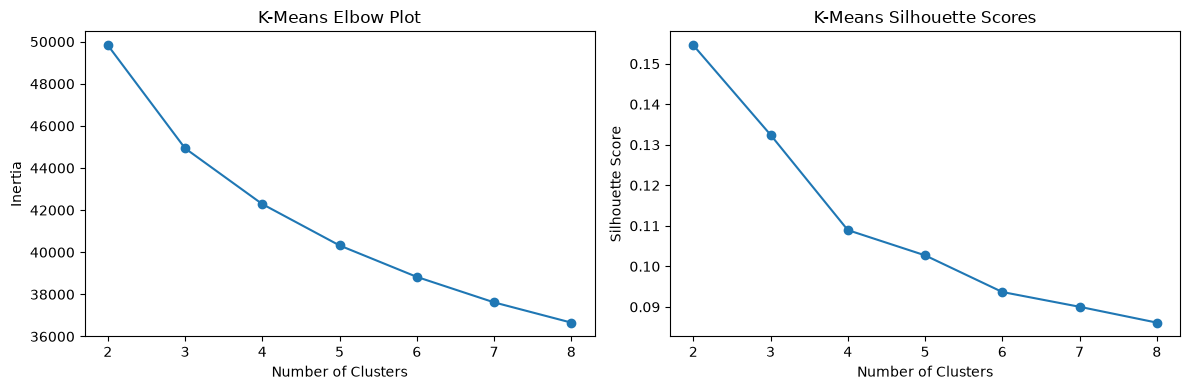

In [23]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    kmeans_results_df["Number of Clusters"],
    kmeans_results_df["Inertia"],
    marker="o"
)
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Inertia")
axes[0].set_title("K-Means Elbow Plot")

axes[1].plot(
    kmeans_results_df["Number of Clusters"],
    kmeans_results_df["Silhouette Score"],
    marker="o"
)
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("K-Means Silhouette Scores")

plt.tight_layout()
plt.show()

#### Selection of K

The highest silhouette score is obtained with two clusters, with a value of approximately 0.155. The score decreases consistently as the number of clusters increases, reaching approximately 0.086 with eight clusters.

The inertia decreases substantially when moving from two to three clusters, but it continues to decline gradually without a sharply defined elbow. The inertia plot therefore does not provide strong evidence for one uniquely correct number of clusters.

A two-cluster solution is selected because it has the highest silhouette score and provides the simplest partition supported by the evaluated results. However, the low silhouette value indicates substantial overlap between the clusters. The selected value of $K=2$ should therefore be treated as a useful analytical partition rather than evidence that the games form two naturally separated populations.

In [24]:
import time

start_time = time.perf_counter()

kmeans_model = KMeans(
    n_clusters=2,
    n_init=20,
    random_state=42
)

kmeans_labels = kmeans_model.fit_predict(
    X_clustering_scaled
)

kmeans_runtime = time.perf_counter() - start_time

clustering_sample_df["KMeans_Cluster"] = kmeans_labels
clustering_projection_df["KMeans_Cluster"] = kmeans_labels

print(f"K-Means runtime: {kmeans_runtime:.3f} seconds")
display(
    clustering_sample_df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Cluster Size")
)

K-Means runtime: 0.057 seconds


,Cluster Size
KMeans_Cluster,
0,2531
1,2469


In [25]:
kmeans_cluster_profiles = (
    clustering_sample_df
    .groupby("KMeans_Cluster")[statistical_columns]
    .mean()
)

display(kmeans_cluster_profiles.round(3))

,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away
KMeans_Cluster,,,,,,,,,,,,
0,95.373,0.432,0.745,0.316,20.540,45.030,92.772,0.421,0.747,0.313,19.127,43.714
1,111.189,0.489,0.774,0.393,25.211,41.722,108.572,0.479,0.770,0.387,23.895,40.706


In [26]:
from sklearn.metrics import (
    davies_bouldin_score,
    calinski_harabasz_score
)

kmeans_silhouette = silhouette_score(
    X_clustering_scaled,
    kmeans_labels
)

kmeans_davies_bouldin = davies_bouldin_score(
    X_clustering_scaled,
    kmeans_labels
)

kmeans_calinski_harabasz = calinski_harabasz_score(
    X_clustering_scaled,
    kmeans_labels
)

kmeans_metrics_df = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ],
    "Value": [
        kmeans_silhouette,
        kmeans_davies_bouldin,
        kmeans_calinski_harabasz
    ]
})

display(kmeans_metrics_df.round(3))

,Metric,Value
0,Silhouette Score,0.150
1,Davies-Bouldin Index,2.147
2,Calinski-Harabasz Index,1015.062


In [27]:
scaled_clustering_df = pd.DataFrame(
    X_clustering_scaled,
    columns=statistical_columns,
    index=clustering_sample_df.index
)

scaled_clustering_df["Cluster"] = kmeans_labels

global_average_variance = (
    scaled_clustering_df[statistical_columns]
    .var()
    .mean()
)

cluster_average_variance = (
    scaled_clustering_df
    .groupby("Cluster")[statistical_columns]
    .var()
    .mean(axis=1)
)

cluster_sizes = (
    scaled_clustering_df["Cluster"]
    .value_counts()
    .sort_index()
)

variance_comparison_df = pd.DataFrame({
    "Cluster Size": cluster_sizes,
    "Average Within-Cluster Variance": cluster_average_variance
})

variance_comparison_df["Ratio to Global Variance"] = (
    variance_comparison_df["Average Within-Cluster Variance"]
    / global_average_variance
)

display(variance_comparison_df.round(3))
print(f"Global average variance: {global_average_variance:.3f}")

,Cluster Size,Average Within-Cluster Variance,Ratio to Global Variance
Cluster,,,
0,2531,0.814,0.814
1,2469,0.848,0.849


Global average variance: 0.999


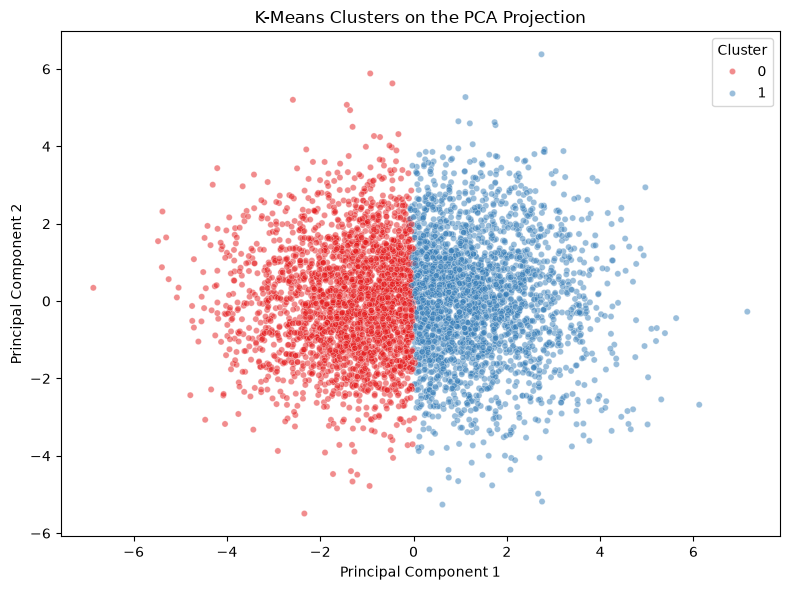

In [28]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=clustering_projection_df,
    x="PC1",
    y="PC2",
    hue="KMeans_Cluster",
    palette="Set1",
    s=20,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters on the PCA Projection")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

#### K-Means Results and Interpretation

**Cluster sizes**

The selected two-cluster solution produces two nearly balanced groups. Cluster 0 contains 2,531 games, while Cluster 1 contains 2,469 games. The result is therefore not driven by one very small group being separated from the rest of the observations.

**Real-world interpretation**

Cluster 0 represents games with relatively low offensive production. Home teams in this cluster scored an average of approximately 95.37 points, while away teams scored approximately 92.77 points. The cluster also has lower field-goal percentages, three-point percentages, free-throw percentages, and assist totals.

At the same time, Cluster 0 has higher average rebound totals: approximately 45.03 for home teams and 43.71 for away teams. Lower shooting efficiency creates more missed shots and therefore more opportunities for rebounds.

Cluster 1 represents games with stronger offensive production. Home and away teams scored approximately 111.19 and 108.57 points on average. The cluster also has higher shooting percentages and more assists, while its average rebound totals are lower.

The two clusters can therefore be interpreted approximately as:

- Cluster 0: lower-scoring, lower-efficiency, higher-rebounding games
- Cluster 1: higher-scoring, higher-efficiency, lower-rebounding games

These profiles may reflect differences in game pace, shooting performance, playing era, overtime, or combinations of these factors. K-Means alone cannot determine which underlying cause produced the separation.

**Clustering metrics**

The final silhouette score is approximately 0.150. This low value indicates that many observations are not substantially closer to their assigned cluster than to the other cluster.

The Davies-Bouldin index is approximately 2.147. Because lower values indicate more compact and separated clusters, this value also suggests considerable overlap. The Calinski-Harabasz index is approximately 1,015, but this metric has no universal absolute threshold and will be more informative when compared with the results of other clustering methods on the same sample.

**Within-cluster variance**

The global average variance of the standardized features is approximately 0.999. The average within-cluster variance is approximately 0.814 in Cluster 0 and 0.848 in Cluster 1. These values correspond to approximately 81.4% and 84.9% of the global variance.

The reduction in variance shows that the partition creates groups that are somewhat more internally homogeneous than the complete sample. However, most of the original variance remains within each cluster, so the groups are not highly compact.

Average within-cluster variance is useful because it directly measures whether the partition reduces variation. Calculating it on standardized features prevents variables with large numerical scales from dominating the result.

Nevertheless, the measure has important limitations. It averages the variances of separate features, ignores covariance and cluster geometry, and does not directly measure separation between clusters. It may also favor solutions containing more clusters. The silhouette score and Davies-Bouldin index provide useful alternatives because they consider both cohesion and separation.

**PCA visualization**

The PCA visualization shows that K-Means separates the games mainly along the first principal component. This is consistent with the interpretation of `PC1` as a general offensive-performance dimension.

However, the two colors form adjacent and overlapping regions rather than clearly disconnected groups. The boundary near the center of the projection reflects the centroid-based decision rule used by K-Means. The visualization supports the metric results: K-Means creates an interpretable partition of a continuous cloud, but it does not reveal two strongly separated natural populations.

**Computational performance**

The final K-Means fit required approximately 0.066 seconds on the 5,000-game sample. This confirms that K-Means is computationally efficient for the present dataset. Its scalability is one of its main advantages, although computational efficiency does not imply that its cluster assumptions are correct.

### DBSCAN

#### Mathematical Intuition, Assumptions, Strengths, and Weaknesses

DBSCAN defines clusters as connected regions of high observation density. It uses two main parameters:

- $\varepsilon$ (`eps`) defines the maximum distance between neighboring observations.
- `min_samples` defines the minimum number of observations required within an $\varepsilon$-neighborhood for an observation to be considered a core point.

A cluster begins with a core point and expands through neighboring core points. Observations that are not reachable from a dense region are labeled as noise rather than being forced into a cluster.

DBSCAN does not require the number of clusters to be specified in advance. It can detect irregularly shaped clusters and explicitly identify low-density observations. These properties are important when the data may contain anomalous games.

Its main limitations are its sensitivity to `eps` and `min_samples`, difficulty handling clusters with different densities, and reduced effectiveness in high-dimensional spaces. As dimensionality increases, distances tend to become more similar, making it harder to distinguish dense neighborhoods from sparse ones.

The features are standardized so that the distance calculation is not dominated by variables measured on larger numerical scales.

#### Parameter Selection

A common starting point for `min_samples` is approximately twice the number of dimensions. Because the feature matrix contains 12 variables, `min_samples` is initially set to 24.

A k-distance plot is used to guide the selection of `eps`. For each observation, the distance to its 24th nearest neighbor is calculated and the distances are sorted. A sharp increase in the curve may indicate a transition between dense observations and lower-density observations.

In [29]:
from sklearn.neighbors import NearestNeighbors

dbscan_min_samples = 24

nearest_neighbors = NearestNeighbors(
    n_neighbors=dbscan_min_samples
)

neighbor_distances, _ = nearest_neighbors.fit(
    X_clustering_scaled
).kneighbors(X_clustering_scaled)

k_distances = pd.Series(
    neighbor_distances[:, -1]
).sort_values().reset_index(drop=True)

display(
    k_distances.quantile(
        [0.50, 0.75, 0.90, 0.95, 0.97, 0.99]
    ).to_frame("24th-Neighbor Distance")
)

,24th-Neighbor Distance
0.50,2.230180
0.75,2.511487
0.90,2.815606
0.95,3.045408
0.97,3.194701
0.99,3.497560


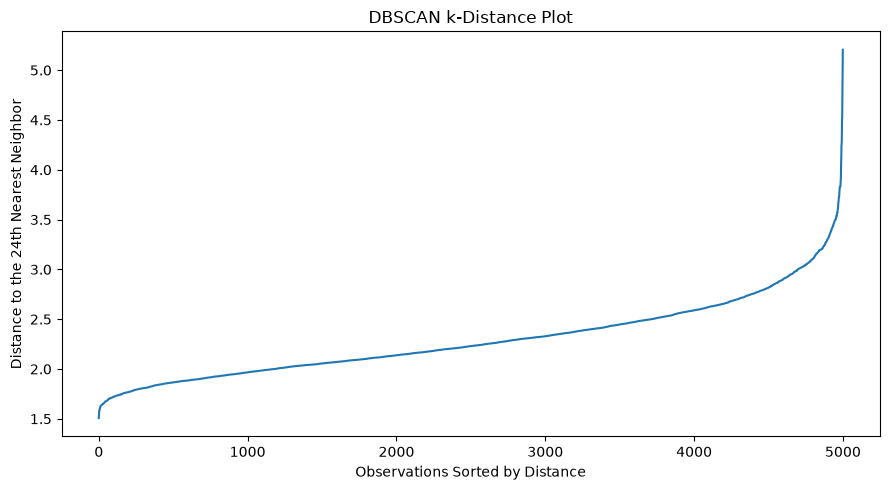

In [30]:
plt.figure(figsize=(9, 5))

plt.plot(k_distances)

plt.xlabel("Observations Sorted by Distance")
plt.ylabel("Distance to the 24th Nearest Neighbor")
plt.title("DBSCAN k-Distance Plot")
plt.tight_layout()
plt.show()

#### DBSCAN Parameter Evaluation

The k-distance curve rises gradually across most observations and becomes noticeably steeper at distances of approximately 3.0 to 3.2.

The 95th percentile of the 24th-neighbor distance is approximately 3.05, while the 97th percentile is approximately 3.19. These values provide a reasonable region in which to examine the `eps` parameter.

Because the curve does not contain one sharply defined elbow, several nearby values will be compared. The comparison will examine the number of clusters and the proportion of observations labeled as noise. This sensitivity analysis is important because a small change in `eps` may substantially change the DBSCAN result.

In [31]:
from sklearn.cluster import DBSCAN

dbscan_parameter_results = []

for eps_value in [2.6, 2.8, 3.0, 3.2, 3.4]:
    dbscan_model = DBSCAN(
        eps=eps_value,
        min_samples=dbscan_min_samples
    )

    dbscan_labels = dbscan_model.fit_predict(
        X_clustering_scaled
    )

    number_of_clusters = len(
        set(dbscan_labels) - {-1}
    )

    number_of_noise_points = (
        dbscan_labels == -1
    ).sum()

    dbscan_parameter_results.append({
        "eps": eps_value,
        "Number of Clusters": number_of_clusters,
        "Noise Points": number_of_noise_points,
        "Noise Percentage": (
            number_of_noise_points /
            len(dbscan_labels) * 100
        )
    })

dbscan_parameter_results_df = pd.DataFrame(
    dbscan_parameter_results
)

display(dbscan_parameter_results_df.round(3))

,eps,Number of Clusters,Noise Points,Noise Percentage
0,2.6,1,105,2.10
1,2.8,1,45,0.90
2,3.0,1,21,0.42
3,3.2,1,8,0.16
4,3.4,1,7,0.14


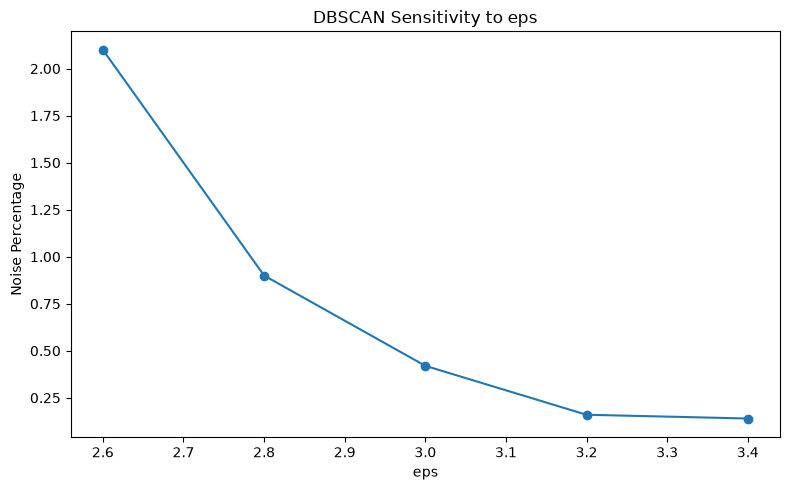

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    dbscan_parameter_results_df["eps"],
    dbscan_parameter_results_df["Noise Percentage"],
    marker="o"
)

plt.xlabel("eps")
plt.ylabel("Noise Percentage")
plt.title("DBSCAN Sensitivity to eps")
plt.tight_layout()
plt.show()

#### Selection of DBSCAN Parameters

All evaluated `eps` values produce one density-based cluster together with a varying number of noise observations. This suggests that the standardized games form one connected region rather than several clearly separated density regions.

As `eps` increases from 2.6 to 3.4, the percentage of observations labeled as noise decreases from 2.10% to 0.14%. This demonstrates the sensitivity of DBSCAN to its neighborhood-radius parameter.

The final model uses `eps=3.0` and `min_samples=24`. The selected `eps` value is close to the 95th percentile of the 24th-neighbor distances and lies near the beginning of the steeper region in the k-distance curve.

This choice is intended to preserve the main connected region while identifying a small number of low-density observations. It is not evidence that 3.0 is a uniquely correct value. Nearby parameter choices produce the same one-cluster structure but different definitions of noise.

In [33]:
start_time = time.perf_counter()

dbscan_model = DBSCAN(
    eps=3.0,
    min_samples=dbscan_min_samples
)

dbscan_labels = dbscan_model.fit_predict(
    X_clustering_scaled
)

dbscan_runtime = time.perf_counter() - start_time

clustering_sample_df["DBSCAN_Cluster"] = dbscan_labels
clustering_projection_df["DBSCAN_Cluster"] = dbscan_labels

display(
    clustering_sample_df["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Number of Observations")
)

print(f"DBSCAN runtime: {dbscan_runtime:.3f} seconds")

,Number of Observations
DBSCAN_Cluster,
-1,21
0,4979


DBSCAN runtime: 0.329 seconds


In [34]:
dbscan_profiles = (
    clustering_sample_df
    .groupby("DBSCAN_Cluster")[statistical_columns]
    .mean()
)

display(dbscan_profiles.round(3))

,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away
DBSCAN_Cluster,,,,,,,,,,,,
-1,103.095,0.454,0.703,0.376,24.333,41.571,107.381,0.456,0.686,0.380,24.429,46.238
0,103.183,0.460,0.760,0.354,22.840,43.404,100.545,0.450,0.759,0.349,21.469,42.212


In [35]:
dbscan_scaled_df = pd.DataFrame(
    X_clustering_scaled,
    columns=statistical_columns,
    index=clustering_sample_df.index
)

dbscan_scaled_df["DBSCAN_Cluster"] = dbscan_labels

dbscan_variance_df = (
    dbscan_scaled_df
    .groupby("DBSCAN_Cluster")[statistical_columns]
    .var()
    .mean(axis=1)
    .to_frame("Average Variance")
)

dbscan_variance_df["Ratio to Global Variance"] = (
    dbscan_variance_df["Average Variance"]
    / global_average_variance
)

display(dbscan_variance_df.round(3))

,Average Variance,Ratio to Global Variance
DBSCAN_Cluster,,
-1,3.373,3.375
0,0.989,0.990


In [36]:
dbscan_cluster_count = len(
    set(dbscan_labels) - {-1}
)

if dbscan_cluster_count >= 2:
    non_noise_mask = dbscan_labels != -1

    dbscan_silhouette = silhouette_score(
        X_clustering_scaled[non_noise_mask],
        dbscan_labels[non_noise_mask]
    )

    print(f"DBSCAN silhouette score: {dbscan_silhouette:.3f}")
else:
    print(
        "Silhouette, Davies-Bouldin, and Calinski-Harabasz "
        "scores are not defined because DBSCAN found only "
        "one non-noise cluster."
    )

Silhouette, Davies-Bouldin, and Calinski-Harabasz scores are not defined because DBSCAN found only one non-noise cluster.


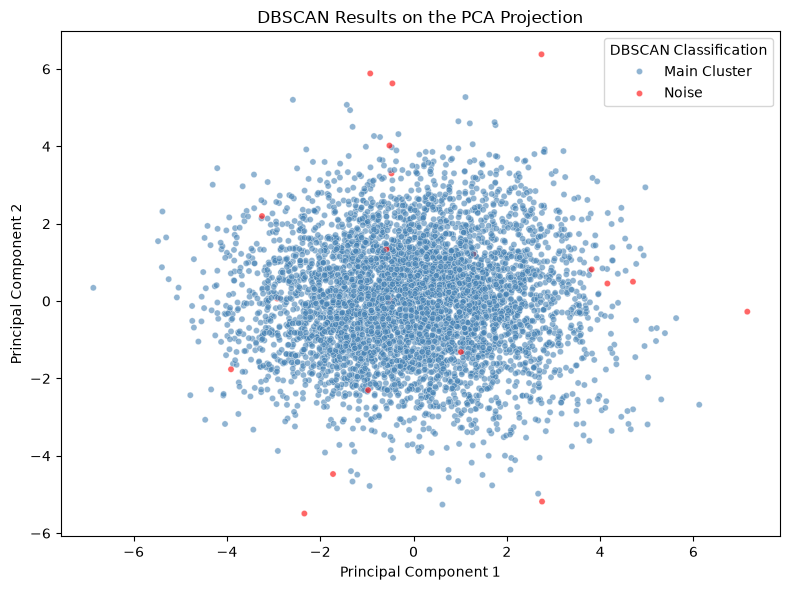

In [37]:
dbscan_plot_df = clustering_projection_df.copy()

dbscan_plot_df["DBSCAN Group"] = (
    dbscan_plot_df["DBSCAN_Cluster"]
    .map({
        -1: "Noise",
        0: "Main Cluster"
    })
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=dbscan_plot_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN Group",
    palette={
        "Main Cluster": "steelblue",
        "Noise": "red"
    },
    s=20,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Results on the PCA Projection")
plt.legend(title="DBSCAN Classification")
plt.tight_layout()
plt.show()

#### DBSCAN Results and Interpretation

**Cluster and noise structure**

The final DBSCAN model identifies one main density-connected cluster containing 4,979 games and labels 21 games as noise. The noise observations represent approximately 0.42% of the 5,000-game sample.

The result indicates that the standardized observations form one broadly connected density region rather than several separated high-density groups. Unlike K-Means, DBSCAN does not force the continuous dataset into a predetermined number of clusters.

**Real-world interpretation**

The average statistical profile of the noise observations does not represent one consistent type of game. Compared with the main cluster, the noise group has lower average free-throw percentages, higher away-team points, more assists, and more away-team rebounds. However, these averages combine only 21 observations that may be unusual for different reasons.

DBSCAN noise should therefore not be interpreted as a coherent basketball category. One game may be unusual because of poor free-throw shooting, while another may be unusual because of high scoring, assists, rebounds, or a combination of several features.

**Variance comparison**

The average variance of the main DBSCAN cluster is approximately 0.989, which is close to the global standardized variance of 0.999. This confirms that almost all of the original variation remains inside the main connected region.

The average variance of the noise observations is approximately 3.373, or about 3.38 times the global variance. This high value is consistent with the purpose of the noise label: the observations are widely dispersed and do not form a compact cluster.

The variance of the noise group should be interpreted cautiously because DBSCAN noise is not a cluster. It is a collection of observations that are not sufficiently connected to a dense region and may be unrelated to one another.

**Clustering metrics**

Silhouette, Davies-Bouldin, and Calinski-Harabasz scores require at least two non-noise clusters. Because DBSCAN identifies only one such cluster, these metrics are not defined for the final result.

Treating all noise observations as a second cluster would be methodologically misleading. DBSCAN does not claim that the noise points form one internally coherent group.

**PCA visualization**

Most noise observations appear near the outer boundaries of the 2D PCA projection, supporting the conclusion that they have unusual feature combinations.

A few red observations appear closer to the central region of the projection. This is not necessarily contradictory: the visualization shows only the first two principal components and omits approximately 55% of the original variance. A game may appear ordinary in the 2D projection while being unusual in one or more omitted dimensions.

**Parameter sensitivity**

The proportion of noise changes from 2.10% at `eps=2.6` to 0.14% at `eps=3.4`. This demonstrates that the definition of a low-density observation is highly sensitive to the selected neighborhood radius.

However, the main structural conclusion is stable across the tested range: every evaluated parameter value produces one non-noise cluster. DBSCAN therefore provides no evidence of multiple density-separated groups in this dataset.

**Computational performance**

The final DBSCAN fit required approximately 0.337 seconds, compared with approximately 0.066 seconds for the final K-Means fit. DBSCAN was therefore roughly five times slower on the current sample, although both runtimes remain practical.

DBSCAN may scale less effectively as the number of observations and dimensions increases because neighborhood searches become more expensive and distances become less informative in high-dimensional space.

### Hierarchical Clustering

#### Mathematical Intuition, Assumptions, Strengths, and Weaknesses

Agglomerative hierarchical clustering begins with every observation in its own cluster. At each step, the two clusters that are considered closest are merged. This process continues until all observations belong to one hierarchy.

The analysis uses Ward linkage. Ward's method selects the merge that produces the smallest increase in within-cluster sum of squared distances. For clusters $A$ and $B$, the increase associated with a merge is proportional to:

$$
\Delta(A,B)=
\frac{|A||B|}{|A|+|B|}
\left\lVert \mu_A-\mu_B \right\rVert^2
$$

where $|A|$ and $|B|$ are the cluster sizes and $\mu_A$ and $\mu_B$ are their centroids.

Ward linkage generally favors compact clusters and relies on Euclidean distance. It therefore has assumptions similar to K-Means and may perform poorly when the true clusters have irregular shapes or very different spreads.

A major strength of hierarchical clustering is that it produces a hierarchy rather than requiring one fixed partition at the beginning. The hierarchy can be visualized with a dendrogram and examined at different numbers of clusters.

Its main weaknesses are its high computational and memory requirements, sensitivity to feature scaling and extreme observations, and the fact that early merges cannot be reversed. These limitations justify applying the method to the common 5,000-game sample rather than all 26,523 games.

#### Selecting the Number of Clusters

A Ward-linkage hierarchy is constructed once. The hierarchy is then cut at values from two to eight clusters, and each partition is evaluated using the silhouette score.

A truncated dendrogram is used to examine the upper levels of the hierarchy. The dendrogram does not display every individual game label because doing so would be unreadable for 5,000 observations.

In [38]:
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    fcluster
)

start_time = time.perf_counter()

hierarchical_linkage = linkage(
    X_clustering_scaled,
    method="ward"
)

hierarchical_runtime = time.perf_counter() - start_time

print(
    f"Hierarchical linkage runtime: "
    f"{hierarchical_runtime:.3f} seconds"
)

Hierarchical linkage runtime: 0.265 seconds


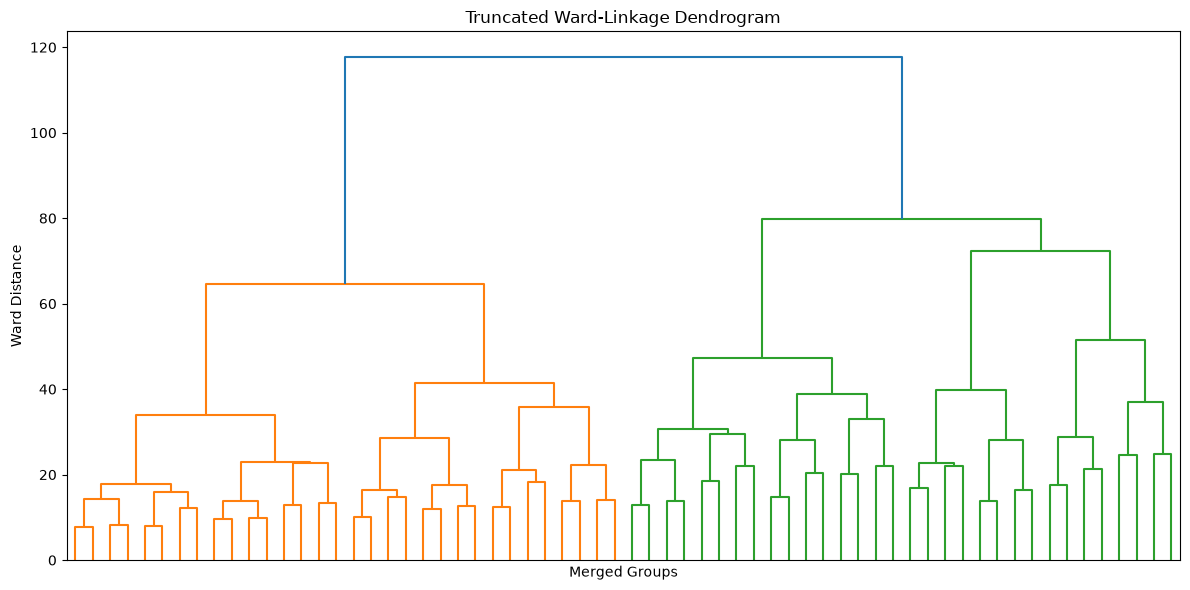

In [39]:
plt.figure(figsize=(12, 6))

dendrogram(
    hierarchical_linkage,
    truncate_mode="level",
    p=5,
    no_labels=True
)

plt.xlabel("Merged Groups")
plt.ylabel("Ward Distance")
plt.title("Truncated Ward-Linkage Dendrogram")
plt.tight_layout()
plt.show()

In [40]:
hierarchical_results = []

for number_of_clusters in range(2, 9):
    hierarchical_labels = fcluster(
        hierarchical_linkage,
        t=number_of_clusters,
        criterion="maxclust"
    ) - 1

    hierarchical_results.append({
        "Number of Clusters": number_of_clusters,
        "Silhouette Score": silhouette_score(
            X_clustering_scaled,
            hierarchical_labels,
            sample_size=2000,
            random_state=42
        )
    })

hierarchical_results_df = pd.DataFrame(
    hierarchical_results
)

display(hierarchical_results_df.round(3))

,Number of Clusters,Silhouette Score
0,2,0.126
1,3,0.061
2,4,0.056
3,5,0.049
4,6,0.038
5,7,0.032
6,8,0.030


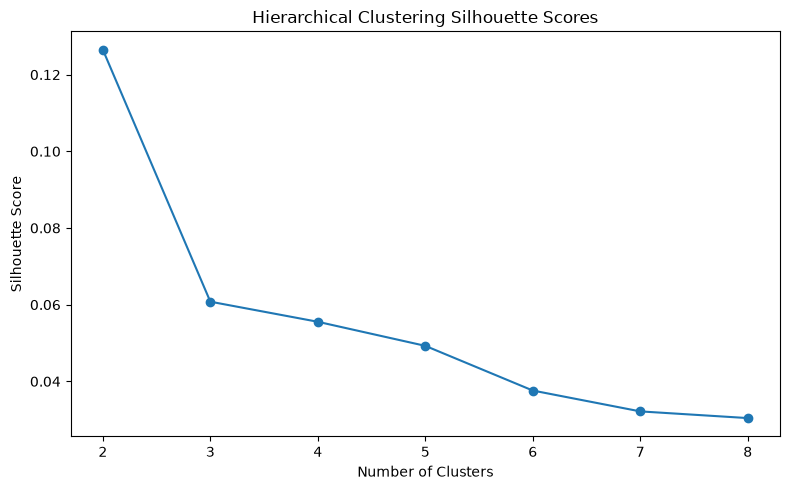

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    hierarchical_results_df["Number of Clusters"],
    hierarchical_results_df["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering Silhouette Scores")
plt.tight_layout()
plt.show()

#### Selection of the Number of Hierarchical Clusters

The highest silhouette score is obtained with two clusters, with a value of approximately 0.126. The score decreases sharply to approximately 0.061 with three clusters and continues to decline as additional clusters are introduced.

The truncated dendrogram also supports examining a two-cluster solution. Its highest merge occurs at a substantially greater Ward distance than the merges immediately below it, indicating that the final two branches are more separated than the smaller groups within each branch.

A two-cluster solution is therefore selected for the final hierarchical partition. This choice is supported by both the silhouette comparison and the upper structure of the dendrogram.

However, the silhouette score remains low. The selected partition should therefore be interpreted as the most defensible cut of the hierarchy among the evaluated alternatives, rather than evidence of two strongly separated natural populations.

In [42]:
hierarchical_labels = fcluster(
    hierarchical_linkage,
    t=2,
    criterion="maxclust"
) - 1

clustering_sample_df["Hierarchical_Cluster"] = (
    hierarchical_labels
)

clustering_projection_df["Hierarchical_Cluster"] = (
    hierarchical_labels
)

print(
    f"Hierarchical linkage runtime: "
    f"{hierarchical_runtime:.3f} seconds"
)

display(
    clustering_sample_df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Cluster Size")
)

Hierarchical linkage runtime: 0.265 seconds


,Cluster Size
Hierarchical_Cluster,
0,1334
1,3666


In [43]:
hierarchical_cluster_profiles = (
    clustering_sample_df
    .groupby("Hierarchical_Cluster")[statistical_columns]
    .mean()
)

display(hierarchical_cluster_profiles.round(3))

,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away
Hierarchical_Cluster,,,,,,,,,,,,
0,111.924,0.492,0.768,0.397,25.153,40.42,111.947,0.496,0.772,0.422,25.236,40.00
1,100.002,0.449,0.756,0.339,22.007,44.48,96.436,0.433,0.754,0.323,20.115,43.04


In [44]:
hierarchical_silhouette = silhouette_score(
    X_clustering_scaled,
    hierarchical_labels
)

hierarchical_davies_bouldin = davies_bouldin_score(
    X_clustering_scaled,
    hierarchical_labels
)

hierarchical_calinski_harabasz = (
    calinski_harabasz_score(
        X_clustering_scaled,
        hierarchical_labels
    )
)

hierarchical_metrics_df = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ],
    "Value": [
        hierarchical_silhouette,
        hierarchical_davies_bouldin,
        hierarchical_calinski_harabasz
    ]
})

display(hierarchical_metrics_df.round(3))

,Metric,Value
0,Silhouette Score,0.126
1,Davies-Bouldin Index,2.366
2,Calinski-Harabasz Index,654.463


In [45]:
hierarchical_scaled_df = pd.DataFrame(
    X_clustering_scaled,
    columns=statistical_columns,
    index=clustering_sample_df.index
)

hierarchical_scaled_df["Cluster"] = (
    hierarchical_labels
)

hierarchical_cluster_variance = (
    hierarchical_scaled_df
    .groupby("Cluster")[statistical_columns]
    .var()
    .mean(axis=1)
)

hierarchical_cluster_sizes = (
    hierarchical_scaled_df["Cluster"]
    .value_counts()
    .sort_index()
)

hierarchical_variance_df = pd.DataFrame({
    "Cluster Size": hierarchical_cluster_sizes,
    "Average Within-Cluster Variance":
        hierarchical_cluster_variance
})

hierarchical_variance_df[
    "Ratio to Global Variance"
] = (
    hierarchical_variance_df[
        "Average Within-Cluster Variance"
    ] / global_average_variance
)

display(hierarchical_variance_df.round(3))

,Cluster Size,Average Within-Cluster Variance,Ratio to Global Variance
Cluster,,,
0,1334,0.893,0.894
1,3666,0.880,0.881


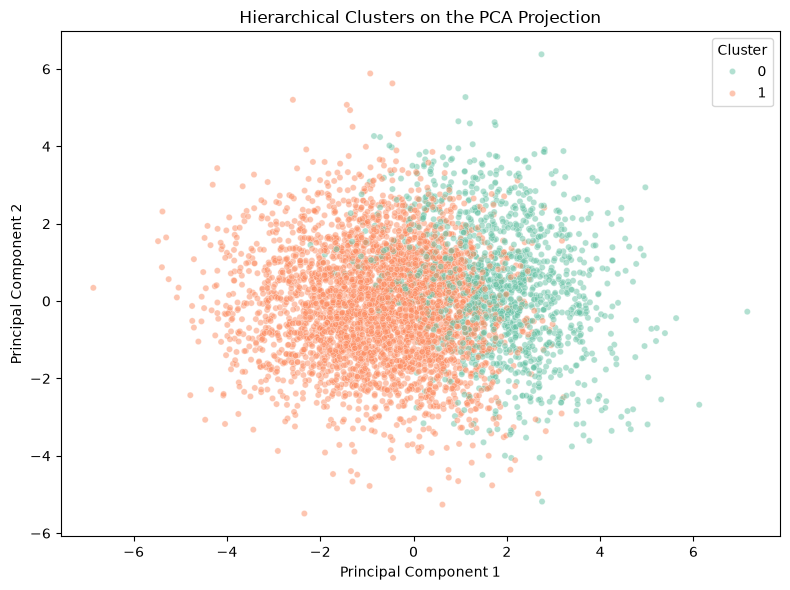

In [46]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=clustering_projection_df,
    x="PC1",
    y="PC2",
    hue="Hierarchical_Cluster",
    palette="Set2",
    s=20,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    "Hierarchical Clusters on the PCA Projection"
)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

#### Hierarchical Clustering Results and Interpretation

**Cluster sizes**

The two-cluster hierarchical solution is unbalanced. Cluster 0 contains 1,334 games, while Cluster 1 contains 3,666 games. The smaller cluster represents approximately 26.7% of the sample.

**Real-world interpretation**

Cluster 0 represents games with high offensive production. Home and away teams scored averages of approximately 111.92 and 111.95 points, respectively. The cluster also has higher field-goal percentages, three-point percentages, free-throw percentages, and assist totals.

Cluster 1 represents lower-scoring and less efficient games. Home teams scored approximately 100.00 points on average, while away teams scored approximately 96.44 points. This cluster also has lower shooting percentages and fewer assists, but higher rebound totals.

The two groups can therefore be interpreted approximately as:

- Cluster 0: high-scoring, high-efficiency games in which both teams performed strongly
- Cluster 1: lower-scoring, lower-efficiency games with more rebounds

The difference in rebounds is consistent with the shooting profiles. Lower shooting efficiency produces more missed shots and therefore more opportunities to collect rebounds.

As with K-Means, these profiles may combine effects from game pace, playing era, overtime, and exceptional shooting performance. Hierarchical clustering does not identify which of these factors is responsible for an individual assignment.

**Clustering metrics**

The silhouette score is approximately 0.126. This indicates weak separation and considerable overlap between the two hierarchical clusters.

The Davies-Bouldin index is approximately 2.366, while the Calinski-Harabasz index is approximately 654.46. On the same sample, K-Means produced a higher silhouette score, a lower Davies-Bouldin index, and a higher Calinski-Harabasz index. According to all three metrics, the K-Means partition is more compact and better separated.

**Within-cluster variance**

The average within-cluster variance is approximately 0.893 for Cluster 0 and 0.880 for Cluster 1. These values correspond to approximately 89.4% and 88.1% of the global variance.

The hierarchical clusters therefore retain most of the variation present in the complete sample. Their variance ratios are also higher than the corresponding K-Means ratios, indicating that Ward hierarchical clustering produced less internally homogeneous groups.

As discussed for K-Means, average variance is informative but incomplete. It does not directly account for covariance, separation, cluster shape, or the unequal cluster sizes. The silhouette and Davies-Bouldin results support the same general conclusion of weak cluster structure.

**PCA visualization**

The PCA projection shows that the clusters overlap substantially. Cluster 0 is concentrated more strongly on the positive side of the first principal component, which is consistent with its high-scoring and high-efficiency profile.

However, observations from both clusters are mixed throughout the central region. The hierarchical partition is not represented by a clean visual boundary, and the point cloud remains continuous rather than divided into disconnected regions.

**Computational performance and stability**

Constructing the Ward-linkage hierarchy required approximately 0.259 seconds on the 5,000-game sample. This was slower than the final K-Means fit but remained practical at the sampled dataset size.

The runtime alone does not reflect the main scalability limitation. Hierarchical clustering must store and process pairwise relationships, so its memory and computational requirements grow rapidly as the number of observations increases. Applying the same method to all 26,523 games would be substantially more demanding.

The hierarchy is deterministic for the same observations, scaling, distance, and linkage rule. However, early merges cannot be reversed, and changes in the sample, extreme observations, or linkage method may alter later parts of the hierarchy.

### Clustering on the Feature Space

The previous analyses clustered games. The following analysis instead treats each of the 12 performance features as an observation.

The standardized feature matrix is transposed so that its shape changes from games by features to features by games. Each feature is then represented by its standardized values across all analyzed games.

Hierarchical clustering is used for the feature space because the dendrogram can reveal nested relationships and possible feature hierarchies. Correlation distance is used instead of ordinary scale-based distance:

$$
d(x,y)=1-\rho(x,y)
$$

where $\rho(x,y)$ is the Pearson correlation between two feature vectors.

Features with a strong positive correlation have a small distance and are expected to merge early. Features with weak or negative correlations have larger distances and merge later.

Average linkage is used to measure the distance between groups of features. Ward linkage is not used here because Ward's objective is defined for Euclidean distances, while the present analysis uses correlation distance.

In [47]:
feature_matrix = pd.DataFrame(
    X_scaled,
    columns=statistical_columns
).T

print(
    f"Feature-space matrix shape: "
    f"{feature_matrix.shape[0]} features × "
    f"{feature_matrix.shape[1]:,} games"
)

Feature-space matrix shape: 12 features × 26,523 games


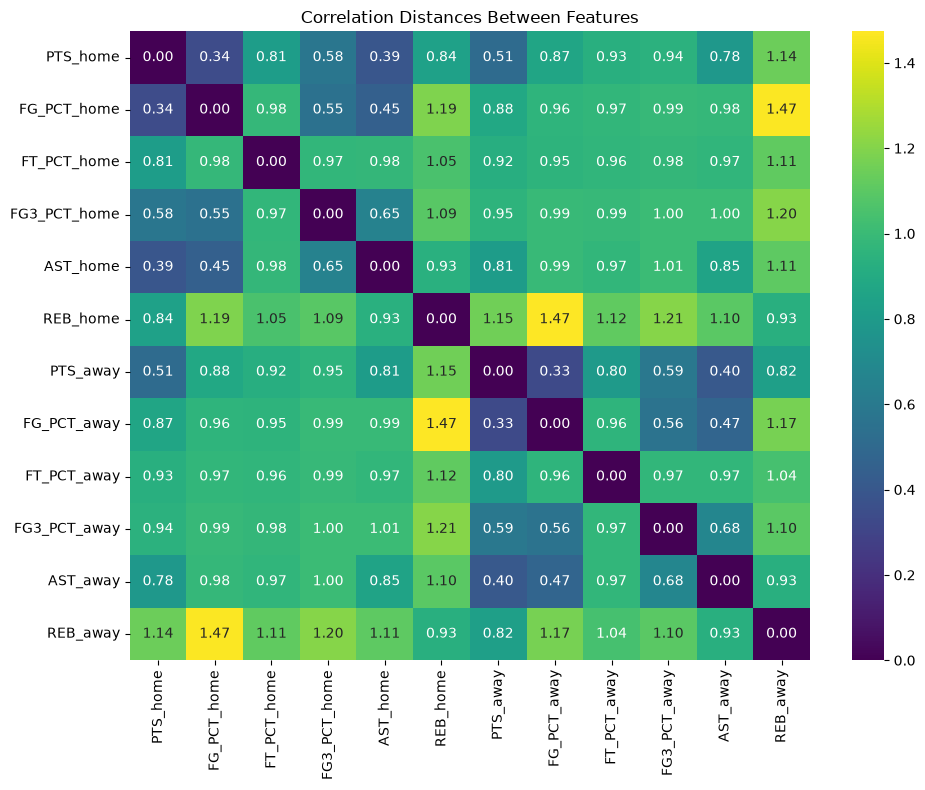

In [48]:
from scipy.spatial.distance import pdist, squareform

feature_distances = pdist(
    feature_matrix,
    metric="correlation"
)

feature_distance_matrix = pd.DataFrame(
    squareform(feature_distances),
    index=statistical_columns,
    columns=statistical_columns
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    feature_distance_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Correlation Distances Between Features")
plt.tight_layout()
plt.show()

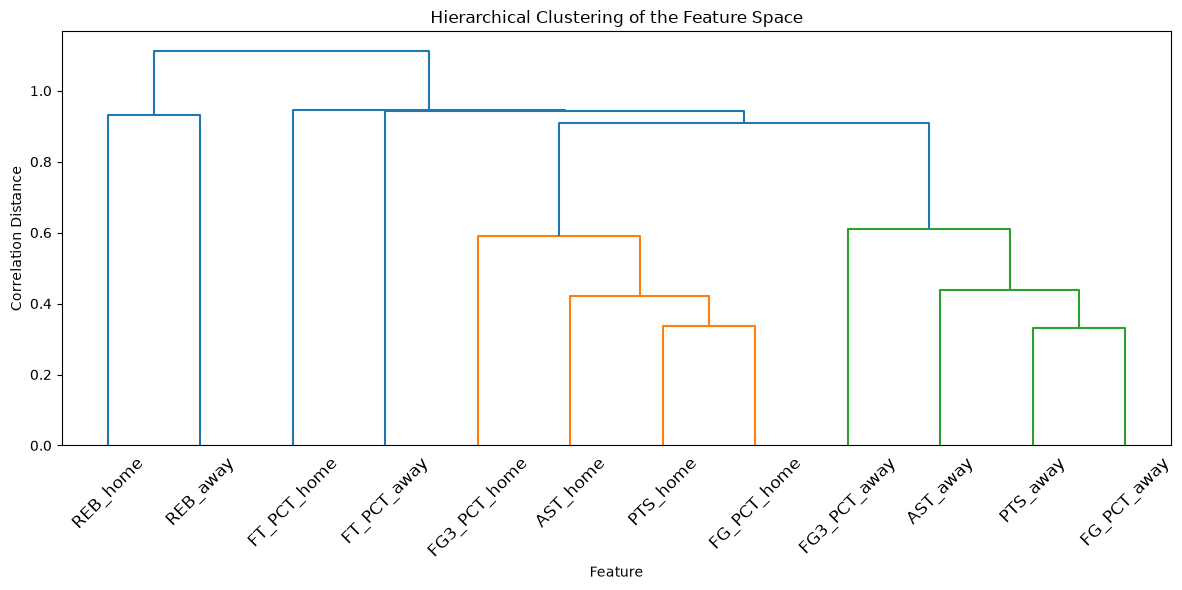

In [49]:
feature_linkage = linkage(
    feature_matrix,
    method="average",
    metric="correlation"
)

plt.figure(figsize=(12, 6))

dendrogram(
    feature_linkage,
    labels=statistical_columns,
    leaf_rotation=45
)

plt.xlabel("Feature")
plt.ylabel("Correlation Distance")
plt.title("Hierarchical Clustering of the Feature Space")
plt.tight_layout()
plt.show()

#### Feature-Space Clustering Results and Interpretation

**Information obtained from clustering the features**

Feature-space clustering shows which variables tend to change together across NBA games. Unlike sample clustering, which groups similar games, this analysis identifies relationships, redundancy, and possible hierarchies among the measured basketball statistics.

A small correlation distance indicates that two features have similar standardized patterns across games. Features that merge early in the dendrogram therefore contain related information.

**Groups of related features**

The clearest relationships are found within the home-team and away-team offensive variables.

For home teams, `PTS_home` and `FG_PCT_home` merge first at a correlation distance of approximately 0.34. `AST_home` then joins this pair, followed by `FG3_PCT_home`.

A similar hierarchy appears for away teams. `PTS_away` and `FG_PCT_away` merge at a distance of approximately 0.33. `AST_away` joins the pair, followed by `FG3_PCT_away`.

These two mirrored structures indicate that points, shooting efficiency, assists, and three-point percentage contain partially overlapping offensive information. However, the distances are not close to zero, so the features are related rather than interchangeable.

The home-team and away-team offensive groups merge only at a later stage. This suggests that the same basketball relationships exist on both sides of a game, while each team's performance still contains substantial independent variation.

**Isolated or different features**

The free-throw percentage variables join the hierarchy relatively late. Their correlation distances from most other variables are close to one, indicating weak linear relationships. This is consistent with their small contributions to the first three principal components.

The rebound variables also remain separate from the main offensive groups until a high linkage distance. Although `REB_home` and `REB_away` eventually form a pair, their correlation distance is approximately 0.93, so their direct positive relationship is weak.

The distance matrix also contains values greater than one. For example, the distance between `FG_PCT_home` and `REB_away` is approximately 1.47, and the distance between `FG_PCT_away` and `REB_home` is also approximately 1.47. A correlation distance greater than one represents a negative correlation. In basketball terms, more missed shots by one team create more rebound opportunities for the opponent.

Because the clustering method is based on positive correlation similarity, negatively related features do not merge early even when their inverse relationship is meaningful. The distance matrix is therefore important for interpreting dependencies that the dendrogram alone may not emphasize.

**Insights not visible from clustering the games**

Sample clustering showed a continuous game population with weak separation. Feature clustering reveals a clearer and more interpretable structure:

- Mirrored home-team and away-team offensive hierarchies
- Partial redundancy among scoring, field-goal percentage, assists, and three-point percentage
- Relative independence of free-throw percentage
- A distinct role for rebounding variables
- Inverse relationships between shooting efficiency and opponent rebounds

These relationships help explain the PCA results. The offensive variables contributed together to the first principal component, while rebounds dominated the third component and free-throw percentages were represented more strongly in later components.

**Domains in which feature clustering is useful**

Feature clustering is particularly useful when a dataset contains many potentially redundant measurements. Examples include:

- Medical datasets containing related laboratory measurements
- Sensor systems in which several devices measure similar physical processes
- Financial datasets containing correlated market indicators
- Genomic datasets containing groups of co-expressed genes
- Survey datasets containing questions that measure similar underlying concepts
- Cybersecurity logs containing related activity indicators

In such settings, feature clustering can support feature selection, dimensionality reduction, detection of duplicated measurements, and interpretation of hidden variable groups.

Overall, clustering the feature space reveals stronger and more interpretable structure than clustering the game observations. The sample-level methods found overlapping partitions, while the feature-level analysis identified meaningful dependencies and a partial hierarchy among the basketball statistics.

In [50]:
kmeans_weighted_variance_ratio = (
    variance_comparison_df["Ratio to Global Variance"]
    * variance_comparison_df["Cluster Size"]
).sum() / len(clustering_sample_df)

hierarchical_weighted_variance_ratio = (
    hierarchical_variance_df["Ratio to Global Variance"]
    * hierarchical_variance_df["Cluster Size"]
).sum() / len(clustering_sample_df)

clustering_comparison_df = pd.DataFrame({
    "Method": [
        "K-Means",
        "DBSCAN",
        "Hierarchical"
    ],
    "Non-Noise Clusters": [
        2,
        dbscan_cluster_count,
        2
    ],
    "Noise Points": [
        0,
        (dbscan_labels == -1).sum(),
        0
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        None,
        hierarchical_silhouette
    ],
    "Davies-Bouldin Index": [
        kmeans_davies_bouldin,
        None,
        hierarchical_davies_bouldin
    ],
    "Calinski-Harabasz Index": [
        kmeans_calinski_harabasz,
        None,
        hierarchical_calinski_harabasz
    ],
    "Weighted Variance Ratio": [
        kmeans_weighted_variance_ratio,
        dbscan_variance_df.loc[
            0, "Ratio to Global Variance"
        ],
        hierarchical_weighted_variance_ratio
    ],
    "Runtime in Seconds": [
        kmeans_runtime,
        dbscan_runtime,
        hierarchical_runtime
    ]
})

display(clustering_comparison_df.round(3))

,Method,Non-Noise Clusters,Noise Points,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Weighted Variance Ratio,Runtime in Seconds
0,K-Means,2,0,0.150,2.147,1015.062,0.831,0.057
1,DBSCAN,1,21,NaN,NaN,NaN,0.990,0.329
2,Hierarchical,2,0,0.126,2.366,654.463,0.884,0.265


In [51]:
from sklearn.metrics import adjusted_rand_score

kmeans_hierarchical_agreement = adjusted_rand_score(
    kmeans_labels,
    hierarchical_labels
)

cluster_assignment_table = pd.crosstab(
    kmeans_labels,
    hierarchical_labels,
    rownames=["K-Means Cluster"],
    colnames=["Hierarchical Cluster"]
)

print(
    f"Adjusted Rand Index: "
    f"{kmeans_hierarchical_agreement:.3f}"
)

display(cluster_assignment_table)

Adjusted Rand Index: 0.238


Hierarchical Cluster,0,1
K-Means Cluster,,
0,72,2459
1,1262,1207


### Discussion

**Comparison of the clustering results**

The three methods produce substantially different descriptions of the same standardized game data.

K-Means divides the sample into two nearly balanced groups representing lower-offense and higher-offense games. Hierarchical clustering also produces an interpretable two-group division, but its high-offense cluster is smaller and more selective. DBSCAN does not identify multiple density-separated groups and instead describes the data as one connected population with 21 low-density observations.

According to the available internal evaluation metrics, K-Means produces the strongest partition. Its silhouette score of approximately 0.150 is higher than the hierarchical score of 0.126. Its Davies-Bouldin index is lower, and its Calinski-Harabasz index is higher. However, the low silhouette values of both methods indicate that neither partition contains strongly separated clusters.

The weighted within-cluster variance ratio is approximately 0.831 for K-Means and 0.884 for hierarchical clustering. K-Means therefore achieves a larger reduction in internal variance. The main DBSCAN cluster retains approximately 99.0% of the global variance, which is consistent with its inclusion of almost the entire sample in one connected region.

**Agreement between K-Means and hierarchical clustering**

The Adjusted Rand Index between the K-Means and hierarchical assignments is approximately 0.238. This indicates limited agreement between the two partitions after correcting for agreement that could occur by chance.

The assignment table shows that 2,459 of the 2,531 K-Means Cluster 0 games are assigned to Hierarchical Cluster 1. The lower-offense group is therefore relatively consistent across the two methods.

In contrast, K-Means Cluster 1 is divided almost evenly between the two hierarchical groups. Of its 2,469 games, 1,262 are assigned to Hierarchical Cluster 0 and 1,207 to Hierarchical Cluster 1. Hierarchical clustering therefore isolates a narrower subset of the higher-offense games, while K-Means uses a broader high-offense category.

**Why the algorithms produce different clusters**

K-Means directly optimizes the distance between observations and cluster centroids. It searches for a partition that minimizes the total within-cluster sum of squared distances.

Ward hierarchical clustering builds a sequence of irreversible merges. Its final two-cluster solution depends on the complete merge history, so it does not necessarily minimize the same objective as a direct two-cluster K-Means fit.

DBSCAN uses a fundamentally different definition. It searches for dense connected regions and does not force every observation into a cluster. The continuous density of the NBA game data allows almost all observations to remain connected, producing one main cluster rather than a high-offense versus low-offense division.

The disagreement is therefore not evidence that one implementation failed. Each algorithm answers a different structural question.

**Sensitivity to hyperparameters**

K-Means is sensitive to the selected value of $K$ and to centroid initialization. Multiple initializations were used to reduce initialization sensitivity, but the choice of two clusters still determines the level at which the continuous point cloud is divided.

DBSCAN is highly sensitive to `eps`. Increasing `eps` from 2.6 to 3.4 reduces the noise percentage from 2.10% to 0.14%. The number of non-noise clusters remains one, but the definition of which games are sufficiently isolated changes substantially.

Hierarchical clustering is sensitive to the linkage method, distance measure, number of clusters selected from the hierarchy, and sampled observations. Ward linkage favors compact clusters, while a different linkage rule could produce a different hierarchy.

All three methods are sensitive to feature scaling. Without standardization, point and rebound totals would have much larger numerical influence than shooting percentages.

**Cluster geometry**

The PCA projections show a continuous, approximately elliptical point cloud rather than disconnected groups.

K-Means divides this geometry using centroid-based boundaries. The resulting split occurs mainly along the first principal component, which represents general offensive performance.

Ward hierarchical clustering also favors compact Euclidean groups, but its merge history produces a smaller high-offense region and a broader second cluster. Considerable overlap remains in the PCA projection.

DBSCAN is capable of identifying irregularly shaped clusters, but it requires them to be separated by lower-density regions. No such separation is visible in the current data, so the observations remain connected as one main cluster.

**Density-based versus centroid-based approaches**

Centroid-based methods can produce a useful partition even when the data contains no natural gaps. This property makes K-Means useful for segmentation, but it also means that the existence of clusters is partly imposed by the selected value of $K$.

Density-based methods do not require a predetermined number of clusters and can leave observations unassigned as noise. This makes DBSCAN more cautious about claiming cluster structure. However, its results depend strongly on the neighborhood parameters, especially in standardized high-dimensional data.

For the NBA dataset, the centroid-based methods produce interpretable performance segments, while the density-based method provides stronger evidence that these segments are parts of one continuous population rather than naturally separated groups.

**Situations in which clustering may fail**

Clustering may fail or produce misleading results in several situations:

- The data may vary along continuous dimensions without containing natural groups.
- Different clusters may have unequal densities, sizes, or shapes.
- Euclidean distance may not reflect meaningful domain similarity.
- High dimensionality may cause distances between observations to become less distinguishable.
- Extreme observations may pull centroids or influence hierarchical merges.
- A random sample may omit rare groups or unusual observations.
- Historical changes in basketball style may create gradual temporal variation rather than distinct populations.
- Results may depend more strongly on parameter choices than on stable underlying structure.

The present analysis exhibits several of these risks. The low silhouette scores, overlapping PCA projections, parameter sensitivity, and limited agreement between algorithms indicate that the discovered groups should not be treated as objectively correct categories.

**Overall interpretation**

The clustering analysis does not provide strong evidence that NBA games form clearly separated natural clusters.

K-Means provides the most compact and interpretable segmentation among the evaluated methods, separating lower-offense and higher-offense games. Hierarchical clustering identifies a related but narrower high-offense group. DBSCAN finds one continuous density region and a small set of low-density observations.

The most defensible conclusion is that offensive game profiles vary mainly along continuous dimensions. The cluster labels are useful summaries of that variation, but their boundaries are method-dependent and should not be interpreted as fixed categories inherent in the data.

## 5. Multi-Dimensional Anomaly Detection

This section applies and compares three anomaly-detection methods:

- Z-Score
- Isolation Forest
- Local Outlier Factor

The methods are applied to all 26,523 complete and non-repeated games rather than to the 5,000-game clustering sample.

### 5.1 Z-Score Method

#### Mathematical Intuition and Assumptions

For feature $j$, the Z-score of observation $i$ is:

$$
z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j}
$$

A large absolute Z-score indicates that the value is far from the feature mean in standard-deviation units.

The feature-wise method flags individual measurements for which $|z_{ij}|>3$. A game is globally classified as anomalous when at least one of its 12 features exceeds this threshold.

The method assumes that the center and standard deviation meaningfully describe each feature. The three-standard-deviation rule is most justified for approximately Gaussian distributions. It may perform poorly for skewed, heavy-tailed, bounded, or multi-modal variables.

In high dimensions, a normal observation has more opportunities to exceed the threshold in at least one feature. The global rule may therefore produce more false positives as the number of dimensions increases. It also evaluates each feature separately and does not directly detect unusual combinations of individually ordinary values.

In [52]:
z_scores_df = pd.DataFrame(
    X_scaled,
    columns=statistical_columns,
    index=analysis_df.index
)

zscore_threshold = 3

zscore_feature_flags = (
    z_scores_df.abs() > zscore_threshold
)

zscore_anomaly_mask = (
    zscore_feature_flags.any(axis=1)
)

analysis_df["ZScore_Anomaly"] = (
    zscore_anomaly_mask
)

analysis_df["ZScore_Max_Absolute"] = (
    z_scores_df.abs().max(axis=1)
)

analysis_df["ZScore_Extreme_Feature"] = (
    z_scores_df.abs().idxmax(axis=1)
)

In [53]:
zscore_feature_summary = (
    zscore_feature_flags
    .sum()
    .to_frame("Flagged Values")
)

display(zscore_feature_summary)

zscore_anomaly_count = zscore_anomaly_mask.sum()
zscore_anomaly_percentage = (
    zscore_anomaly_count / len(analysis_df) * 100
)

print(f"Globally flagged games: {zscore_anomaly_count:,}")
print(
    f"Percentage of analyzed games: "
    f"{zscore_anomaly_percentage:.2f}%"
)

,Flagged Values
PTS_home,81
FG_PCT_home,68
FT_PCT_home,128
FG3_PCT_home,189
AST_home,87
REB_home,82
PTS_away,90
FG_PCT_away,74
FT_PCT_away,125
FG3_PCT_away,194


Globally flagged games: 1,198
Percentage of analyzed games: 4.52%


In [54]:
flagged_features_per_game = (
    zscore_feature_flags.sum(axis=1)
)

display(
    flagged_features_per_game
    .value_counts()
    .sort_index()
    .to_frame("Number of Games")
)

,Number of Games
0,25325
1,1082
2,102
3,12
4,2


In [55]:
zscore_top_anomalies = (
    analysis_df.loc[
        zscore_anomaly_mask,
        [
            "GAME_DATE_EST",
            "GAME_ID",
            "SEASON",
            "ZScore_Max_Absolute",
            "ZScore_Extreme_Feature"
        ]
    ]
    .sort_values(
        "ZScore_Max_Absolute",
        ascending=False
    )
    .head(10)
)

display(zscore_top_anomalies)

,GAME_DATE_EST,GAME_ID,SEASON,ZScore_Max_Absolute,ZScore_Extreme_Feature
21675,2018-01-19,21700673,2017,6.134248,FT_PCT_home
7803,2012-01-14,21100174,2011,5.956216,FT_PCT_away
25516,2015-03-20,21401022,2014,5.953046,REB_away
16748,2005-04-06,20401112,2004,5.943661,FG3_PCT_away
16535,2005-10-11,10500005,2005,5.943661,FG3_PCT_away
14402,2007-01-20,20600593,2006,5.943661,FG3_PCT_away
14584,2006-12-27,20600423,2006,5.943661,FG3_PCT_away
17026,2005-02-28,20400833,2004,5.943661,FG3_PCT_away
26420,2014-11-14,21400129,2014,5.895797,FT_PCT_home
14635,2006-12-20,20600375,2006,5.792049,FG3_PCT_home


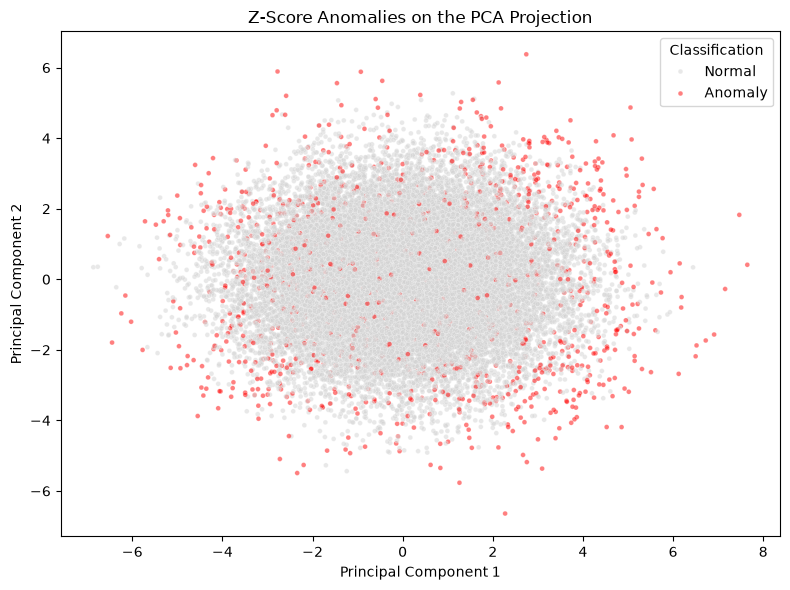

In [56]:
zscore_plot_df = pca_projection_df.copy()

zscore_plot_df["Z-Score Classification"] = (
    analysis_df["ZScore_Anomaly"]
    .map({
        False: "Normal",
        True: "Anomaly"
    })
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=zscore_plot_df,
    x="PC1",
    y="PC2",
    hue="Z-Score Classification",
    palette={
        "Normal": "lightgray",
        "Anomaly": "red"
    },
    s=12,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Z-Score Anomalies on the PCA Projection")
plt.legend(title="Classification")
plt.tight_layout()
plt.show()

#### Z-Score Results and Interpretation

The Z-score method flags 1,198 games, representing approximately 4.52% of the analyzed dataset. Most flagged games exceed the threshold in only one feature: 1,082 games are extreme in one variable, while 116 are extreme in two or more variables.

Three-point percentage produces the largest numbers of feature-wise flags, with 189 home-team and 194 away-team values. The most extreme games are primarily associated with free-throw percentage, three-point percentage, and rebounds.

The method assumes that feature means and standard deviations provide meaningful descriptions of normal behavior. This assumption is imperfect for bounded percentage variables and for distributions with heavier tails. Legitimate games with unusually high or low shooting percentages may therefore be classified as anomalous.

The feature-wise rule is easy to interpret because each flagged game can be linked to a specific variable. However, it cannot detect unusual combinations of moderate values when no individual feature exceeds three standard deviations.

The global rule flags a game when any feature exceeds the threshold. With 12 features, each game has multiple opportunities to be flagged, increasing the risk of false positives. This multiple-comparison effect becomes more severe in higher dimensions.

The PCA visualization places many flagged games near the outer boundaries of the projected cloud, but some appear near its center. These games may be unusual in dimensions omitted from the 2D projection. The visualization therefore cannot fully validate or reject a high-dimensional anomaly classification.

### 5.2 Isolation Forest

#### Mathematical Intuition, Assumptions, Strengths, and Weaknesses

Isolation Forest identifies anomalies by repeatedly selecting a feature and a split value at random. Observations that can be separated from the rest of the data after only a few splits receive shorter average path lengths and are considered more anomalous.

The theoretical anomaly score is based on the expected path length:

$$
s(x)=2^{-\frac{E[h(x)]}{c(n)}}
$$

where $E[h(x)]$ is the average path length of observation $x$ and $c(n)$ normalizes the score for sample size. Short paths produce scores closer to one and indicate stronger anomalies.

Random partitioning allows the method to identify unusual multi-dimensional combinations without calculating every pairwise distance. This makes Isolation Forest relatively efficient in larger datasets.

The method does not require Gaussian features and can model non-linear interactions. However, its results depend on random sampling, tree settings, feature representation, and the assumed contamination rate. In high-dimensional data, irrelevant features may create uninformative random splits and reduce detection quality.

The `contamination` parameter determines the expected proportion of observations labeled as anomalies. It changes the classification threshold rather than establishing a true anomaly rate. For comparability with the Z-score method, the final model uses its observed anomaly proportion of approximately 4.52%.

The implementation below defines a reported anomaly score as the negative of `score_samples`, so a higher reported value represents a more anomalous observation.

In [57]:
from sklearn.ensemble import IsolationForest

isolation_contamination = (
    zscore_anomaly_count / len(analysis_df)
)

start_time = time.perf_counter()

isolation_forest_model = IsolationForest(
    n_estimators=200,
    contamination=isolation_contamination,
    random_state=42,
    n_jobs=-1
)

isolation_predictions = (
    isolation_forest_model.fit_predict(X_scaled)
)

isolation_runtime = time.perf_counter() - start_time

isolation_anomaly_mask = (
    isolation_predictions == -1
)

isolation_anomaly_scores = (
    -isolation_forest_model.score_samples(X_scaled)
)

analysis_df["IsolationForest_Anomaly"] = (
    isolation_anomaly_mask
)

analysis_df["IsolationForest_Score"] = (
    isolation_anomaly_scores
)

print(
    f"Isolation Forest runtime: "
    f"{isolation_runtime:.3f} seconds"
)
print(
    f"Flagged games: "
    f"{isolation_anomaly_mask.sum():,}"
)
print(
    f"Percentage flagged: "
    f"{isolation_anomaly_mask.mean() * 100:.2f}%"
)

Isolation Forest runtime: 0.446 seconds
Flagged games: 1,198
Percentage flagged: 4.52%


,IsolationForest_Score
count,26523.000000
mean,0.439592
std,0.037298
min,0.368384
25%,0.411991
50%,0.432927
75%,0.460525
max,0.638517


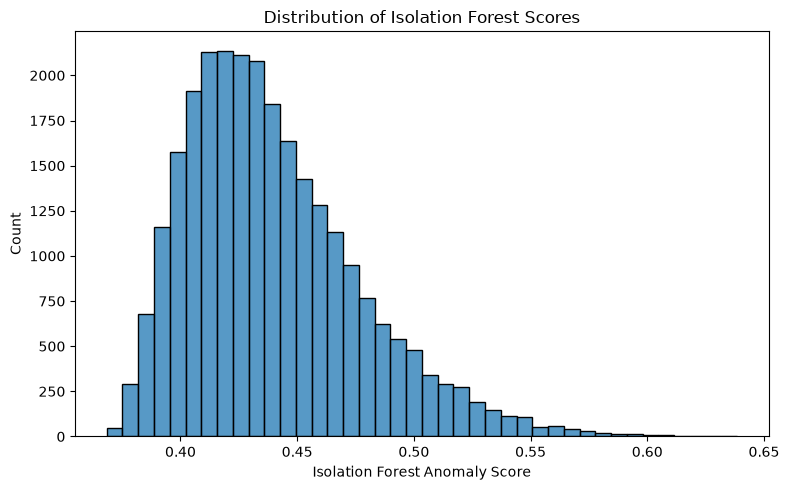

In [58]:
display(
    analysis_df["IsolationForest_Score"]
    .describe()
    .to_frame()
)

plt.figure(figsize=(8, 5))

sns.histplot(
    data=analysis_df,
    x="IsolationForest_Score",
    bins=40
)

plt.xlabel("Isolation Forest Anomaly Score")
plt.title("Distribution of Isolation Forest Scores")
plt.tight_layout()
plt.show()

In [59]:
isolation_top_anomalies = (
    analysis_df[
        [
            "GAME_DATE_EST",
            "GAME_ID",
            "SEASON",
            "IsolationForest_Score"
        ]
    ]
    .sort_values(
        "IsolationForest_Score",
        ascending=False
    )
    .head(10)
)

display(isolation_top_anomalies)

,GAME_DATE_EST,GAME_ID,SEASON,IsolationForest_Score
2153,2021-05-01,22000963,2020,0.638517
25134,2015-10-23,11500106,2015,0.633854
13632,2007-10-19,10700072,2007,0.624141
14599,2006-12-23,20600398,2006,0.623724
12245,2008-10-11,10800035,2008,0.623671
26401,2014-11-16,21400144,2014,0.622742
63,2022-12-14,22200422,2022,0.621004
1878,2021-10-13,12100048,2021,0.611245
17923,2004-05-18,40300206,2003,0.609845
19275,2003-10-08,10300012,2003,0.608358


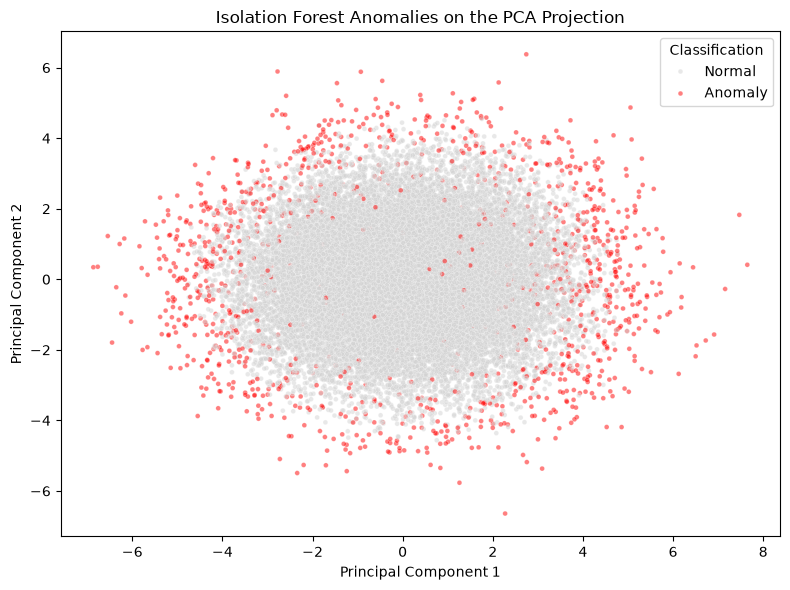

In [60]:
isolation_plot_df = pca_projection_df.copy()

isolation_plot_df["Isolation Forest Classification"] = (
    analysis_df["IsolationForest_Anomaly"]
    .map({
        False: "Normal",
        True: "Anomaly"
    })
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=isolation_plot_df,
    x="PC1",
    y="PC2",
    hue="Isolation Forest Classification",
    palette={
        "Normal": "lightgray",
        "Anomaly": "red"
    },
    s=12,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    "Isolation Forest Anomalies on the PCA Projection"
)
plt.legend(title="Classification")
plt.tight_layout()
plt.show()

#### Isolation Forest Results and Interpretation

Isolation Forest flags 1,198 games, representing 4.52% of the dataset. This number is determined by the selected `contamination` value and should not be interpreted as an independently estimated anomaly prevalence.

The reported scores range from approximately 0.368 to 0.639, with higher values indicating observations isolated by shorter average paths. The right tail of the score distribution contains the strongest anomalies.

Random feature selection and random split points allow Isolation Forest to detect unusual multi-dimensional combinations without assuming Gaussian distributions. However, the result depends on the random trees, feature representation, and contamination threshold. Irrelevant dimensions may also reduce its effectiveness by creating uninformative splits.

Most detected anomalies appear near the edges of the PCA projection, while some appear near its center because the first two components omit 55% of the total variance. The model required approximately 0.445 seconds, making it practical for the current dataset.

### 5.3 Local Outlier Factor (LOF)

#### Mathematical Intuition, Assumptions, Strengths, and Weaknesses

Local Outlier Factor compares the local density around an observation with the densities around its nearest neighbors. An observation receives a high anomaly score when its neighborhood is substantially less dense than the neighborhoods of nearby observations.

This local comparison allows LOF to identify observations that are unusual relative to a nearby subgroup, even when they are not extreme relative to the complete dataset.

The parameter `n_neighbors`, denoted by $k$, controls the size of the local neighborhood. A small value is sensitive to very local patterns and noise, while a large value produces a smoother and more global definition of abnormality.

LOF can detect local anomalies and does not assume Gaussian distributions. Its limitations include sensitivity to $k$, feature scaling, uneven density, and high dimensionality. When distances become less informative, local-density estimates also become less reliable.

The contamination rate is again set to 4.52% for a controlled comparison with the previous methods. Several neighborhood sizes are evaluated before selecting the final model.

In [61]:
from sklearn.neighbors import LocalOutlierFactor

lof_neighbor_values = [10, 20, 35, 50]
lof_masks = {}
lof_scores = {}

for neighbor_count in lof_neighbor_values:
    lof_model = LocalOutlierFactor(
        n_neighbors=neighbor_count,
        contamination=isolation_contamination,
        n_jobs=-1
    )

    lof_predictions = lof_model.fit_predict(
        X_scaled
    )

    lof_masks[neighbor_count] = (
        lof_predictions == -1
    )

    lof_scores[neighbor_count] = (
        -lof_model.negative_outlier_factor_
    )

In [62]:
lof_reference_mask = lof_masks[20]
lof_sensitivity_results = []

for neighbor_count in lof_neighbor_values:
    current_mask = lof_masks[neighbor_count]

    intersection = (
        current_mask & lof_reference_mask
    ).sum()

    union = (
        current_mask | lof_reference_mask
    ).sum()

    lof_sensitivity_results.append({
        "Number of Neighbors": neighbor_count,
        "Flagged Games": current_mask.sum(),
        "Jaccard Agreement with k=20":
            intersection / union
    })

lof_sensitivity_df = pd.DataFrame(
    lof_sensitivity_results
)

display(lof_sensitivity_df.round(3))

,Number of Neighbors,Flagged Games,Jaccard Agreement with k=20
0,10,1198,0.686
1,20,1198,1.000
2,35,1198,0.803
3,50,1198,0.764


#### Selection of the Neighborhood Size

The number of flagged games remains fixed at 1,198 because all models use the same contamination rate. However, the identities of the flagged games change with the neighborhood size.

The agreement between $k=10$ and $k=20$ is approximately 68.6%, indicating sensitivity to very small neighborhoods. Agreement is higher for $k=35$ and $k=50$, at approximately 80.3% and 76.4%.

The final model uses $k=20$. This value preserves a local definition of abnormality while avoiding the greater noise sensitivity observed with $k=10$. The sensitivity results show that LOF classifications are not completely stable and should be interpreted cautiously.

In [63]:
start_time = time.perf_counter()

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=isolation_contamination,
    n_jobs=-1
)

lof_predictions = lof_model.fit_predict(
    X_scaled
)

lof_runtime = time.perf_counter() - start_time

lof_anomaly_mask = (
    lof_predictions == -1
)

lof_anomaly_scores = (
    -lof_model.negative_outlier_factor_
)

analysis_df["LOF_Anomaly"] = lof_anomaly_mask
analysis_df["LOF_Score"] = lof_anomaly_scores

print(f"LOF runtime: {lof_runtime:.3f} seconds")
print(f"Flagged games: {lof_anomaly_mask.sum():,}")
print(
    f"Percentage flagged: "
    f"{lof_anomaly_mask.mean() * 100:.2f}%"
)

LOF runtime: 1.194 seconds
Flagged games: 1,198
Percentage flagged: 4.52%


,LOF_Score
count,26523.000000
mean,1.075294
std,0.085125
min,0.955208
25%,1.017331
50%,1.053644
75%,1.108464
max,2.913289


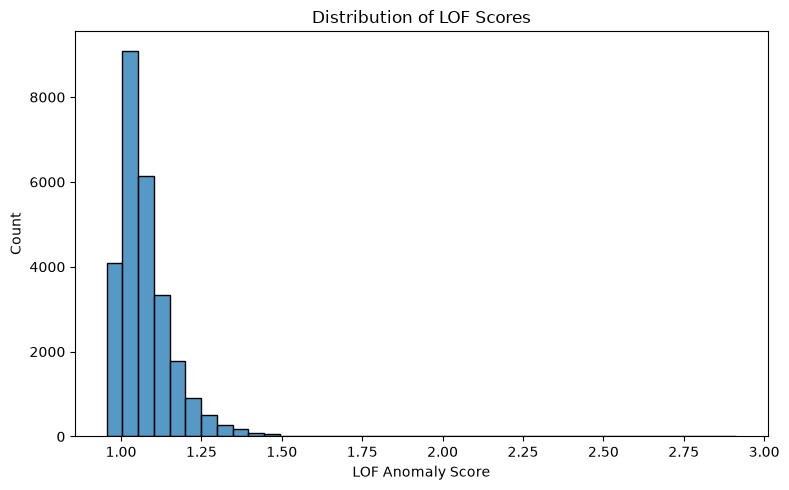

In [64]:
display(
    analysis_df["LOF_Score"]
    .describe()
    .to_frame()
)

plt.figure(figsize=(8, 5))

sns.histplot(
    data=analysis_df,
    x="LOF_Score",
    bins=40
)

plt.xlabel("LOF Anomaly Score")
plt.title("Distribution of LOF Scores")
plt.tight_layout()
plt.show()

In [65]:
lof_top_anomalies = (
    analysis_df[
        [
            "GAME_DATE_EST",
            "GAME_ID",
            "SEASON",
            "LOF_Score"
        ]
    ]
    .sort_values(
        "LOF_Score",
        ascending=False
    )
    .head(10)
)

display(lof_top_anomalies)

,GAME_DATE_EST,GAME_ID,SEASON,LOF_Score
13632,2007-10-19,10700072,2007,2.913289
14402,2007-01-20,20600593,2006,1.993136
2153,2021-05-01,22000963,2020,1.827161
19275,2003-10-08,10300012,2003,1.820503
18411,2004-02-17,20300768,2003,1.818766
20346,2019-01-10,21800619,2018,1.807345
22821,2017-03-01,21600900,2016,1.746515
14584,2006-12-27,20600423,2006,1.732695
14599,2006-12-23,20600398,2006,1.727095
16194,2005-12-03,20500233,2005,1.691278


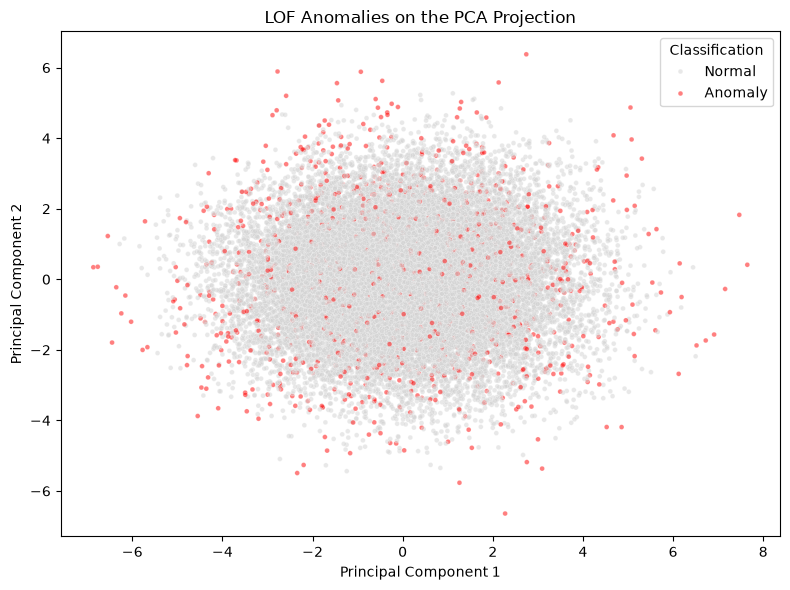

In [66]:
lof_plot_df = pca_projection_df.copy()

lof_plot_df["LOF Classification"] = (
    analysis_df["LOF_Anomaly"]
    .map({
        False: "Normal",
        True: "Anomaly"
    })
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=lof_plot_df,
    x="PC1",
    y="PC2",
    hue="LOF Classification",
    palette={
        "Normal": "lightgray",
        "Anomaly": "red"
    },
    s=12,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("LOF Anomalies on the PCA Projection")
plt.legend(title="Classification")
plt.tight_layout()
plt.show()

#### LOF Results and Interpretation

LOF flags 1,198 games, representing 4.52% of the dataset. This count is fixed by the contamination parameter, while the selected observations depend on their local densities.

The anomaly scores have a median of approximately 1.054 and a maximum of 2.913. Scores near one indicate density similar to neighboring observations, while larger values indicate substantially lower local density.

The PCA projection shows anomalies both near the outer boundaries and within the central region. This is consistent with LOF's local definition: a game can be unusual relative to nearby games without being globally extreme.

The selected anomalies are sensitive to neighborhood size. Agreement with $k=20$ ranges from 68.6% to 80.3% for the alternative tested values. LOF is therefore useful for local anomalies but less stable when neighborhood definitions change.

The final fit required approximately 1.254 seconds, making it slower than both Z-score calculation and Isolation Forest for this dataset.

## 6. Comparison Section

The following analysis compares agreement and disagreement between Z-Score, Isolation Forest, and LOF. All three methods use the same 26,523 games and flag the same overall proportion, allowing their selected observations to be compared directly.

In [67]:
anomaly_methods_df = pd.DataFrame({
    "Z-Score": zscore_anomaly_mask,
    "Isolation Forest": isolation_anomaly_mask,
    "LOF": lof_anomaly_mask
}, index=analysis_df.index)

methods_flagged = anomaly_methods_df.sum(axis=1)

agreement_summary_df = pd.DataFrame({
    "Category": [
        "Flagged by any method",
        "Flagged by all three methods",
        "Flagged by exactly two methods",
        "Flagged by exactly one method"
    ],
    "Number of Games": [
        (methods_flagged >= 1).sum(),
        (methods_flagged == 3).sum(),
        (methods_flagged == 2).sum(),
        (methods_flagged == 1).sum()
    ]
})

display(agreement_summary_df)

,Category,Number of Games
0,Flagged by any method,2460
1,Flagged by all three methods,260
2,Flagged by exactly two methods,614
3,Flagged by exactly one method,1586


In [68]:
method_pattern_summary_df = pd.DataFrame({
    "Pattern": [
        "Z-Score only",
        "Isolation Forest only",
        "LOF only",
        "Z-Score and Isolation Forest only",
        "Z-Score and LOF only",
        "Isolation Forest and LOF only",
        "All three methods"
    ],
    "Number of Games": [
        (
            anomaly_methods_df["Z-Score"]
            & ~anomaly_methods_df["Isolation Forest"]
            & ~anomaly_methods_df["LOF"]
        ).sum(),
        (
            ~anomaly_methods_df["Z-Score"]
            & anomaly_methods_df["Isolation Forest"]
            & ~anomaly_methods_df["LOF"]
        ).sum(),
        (
            ~anomaly_methods_df["Z-Score"]
            & ~anomaly_methods_df["Isolation Forest"]
            & anomaly_methods_df["LOF"]
        ).sum(),
        (
            anomaly_methods_df["Z-Score"]
            & anomaly_methods_df["Isolation Forest"]
            & ~anomaly_methods_df["LOF"]
        ).sum(),
        (
            anomaly_methods_df["Z-Score"]
            & ~anomaly_methods_df["Isolation Forest"]
            & anomaly_methods_df["LOF"]
        ).sum(),
        (
            ~anomaly_methods_df["Z-Score"]
            & anomaly_methods_df["Isolation Forest"]
            & anomaly_methods_df["LOF"]
        ).sum(),
        (
            anomaly_methods_df["Z-Score"]
            & anomaly_methods_df["Isolation Forest"]
            & anomaly_methods_df["LOF"]
        ).sum()
    ]
})

display(method_pattern_summary_df)

,Pattern,Number of Games
0,Z-Score only,522
1,Isolation Forest only,532
2,LOF only,532
3,Z-Score and Isolation Forest only,208
4,Z-Score and LOF only,208
5,Isolation Forest and LOF only,198
6,All three methods,260


In [69]:
method_pairs = [
    ("Z-Score", "Isolation Forest"),
    ("Z-Score", "LOF"),
    ("Isolation Forest", "LOF")
]

pairwise_agreement = []

for first_method, second_method in method_pairs:
    first_mask = anomaly_methods_df[first_method]
    second_mask = anomaly_methods_df[second_method]

    intersection = (
        first_mask & second_mask
    ).sum()

    union = (
        first_mask | second_mask
    ).sum()

    pairwise_agreement.append({
        "Method Pair":
            f"{first_method} vs {second_method}",
        "Shared Anomalies": intersection,
        "Jaccard Agreement": intersection / union
    })

pairwise_agreement_df = pd.DataFrame(
    pairwise_agreement
)

display(pairwise_agreement_df.round(3))

,Method Pair,Shared Anomalies,Jaccard Agreement
0,Z-Score vs Isolation Forest,468,0.243
1,Z-Score vs LOF,468,0.243
2,Isolation Forest vs LOF,458,0.236


In [71]:
example_columns = [
    "GAME_DATE_EST",
    "GAME_ID",
    "ZScore_Extreme_Feature",
    "ZScore_Max_Absolute",
    "IsolationForest_Score",
    "LOF_Score"
]

shared_anomaly_examples_df = (
    analysis_df.loc[
        methods_flagged == 3,
        example_columns
    ]
    .sort_values(
        "IsolationForest_Score",
        ascending=False
    )
    .head(5)
)

display(shared_anomaly_examples_df.round(3))

score_column_by_method = {
    "Z-Score": "ZScore_Max_Absolute",
    "Isolation Forest": "IsolationForest_Score",
    "LOF": "LOF_Score"
}

method_specific_examples = []

for method_name, score_column in score_column_by_method.items():
    method_only_mask = (
        anomaly_methods_df[method_name]
        & (methods_flagged == 1)
    )

    current_examples = (
        analysis_df.loc[
            method_only_mask,
            example_columns
        ]
        .sort_values(score_column, ascending=False)
        .head(3)
        .copy()
    )

    current_examples.insert(
        0,
        "Detection Category",
        f"{method_name} only"
    )

    method_specific_examples.append(current_examples)

method_specific_examples_df = pd.concat(
    method_specific_examples,
    ignore_index=True
)

display(method_specific_examples_df.round(3))

,GAME_DATE_EST,GAME_ID,ZScore_Extreme_Feature,ZScore_Max_Absolute,IsolationForest_Score,LOF_Score
2153,2021-05-01,22000963,PTS_away,3.825,0.639,1.827
25134,2015-10-23,11500106,REB_home,3.567,0.634,1.481
13632,2007-10-19,10700072,PTS_home,5.079,0.624,2.913
14599,2006-12-23,20600398,FG3_PCT_away,3.660,0.624,1.727
63,2022-12-14,22200422,AST_away,3.586,0.621,1.652


,Detection Category,GAME_DATE_EST,GAME_ID,ZScore_Extreme_Feature,ZScore_Max_Absolute,IsolationForest_Score,LOF_Score
0,Z-Score only,2007-02-21,20600801,FG3_PCT_home,4.668,0.475,1.234
1,Z-Score only,2005-11-13,20500094,FG3_PCT_away,4.637,0.464,1.171
2,Z-Score only,2007-02-11,20600758,FT_PCT_home,4.247,0.484,1.238
3,Isolation Forest only,2018-02-07,21700807,PTS_away,2.782,0.603,1.212
4,Isolation Forest only,2012-04-16,21100903,FG_PCT_home,2.783,0.592,1.192
5,Isolation Forest only,2015-03-19,21401018,FT_PCT_away,2.503,0.587,1.241
6,LOF only,2004-11-29,20400199,FG3_PCT_home,2.456,0.506,1.547
7,LOF only,2004-11-17,20400111,FT_PCT_home,2.380,0.512,1.499
8,LOF only,2004-03-06,20300902,PTS_away,2.280,0.482,1.496


In [70]:
start_time = time.perf_counter()

_ = (
    z_scores_df.abs() > zscore_threshold
).any(axis=1)

zscore_runtime = time.perf_counter() - start_time

anomaly_runtime_df = pd.DataFrame({
    "Method": [
        "Z-Score",
        "Isolation Forest",
        "LOF"
    ],
    "Runtime in Seconds": [
        zscore_runtime,
        isolation_runtime,
        lof_runtime
    ]
})

display(anomaly_runtime_df.round(4))

,Method,Runtime in Seconds
0,Z-Score,0.0017
1,Isolation Forest,0.4463
2,LOF,1.1936


### Results and Discussion

The three methods identified 2,460 games as anomalous, but only 260 were detected by all three. Pairwise Jaccard agreement was low (0.236–0.243), showing that each method captures a different type of unusual game. Z-Score detects extreme individual statistics, Isolation Forest identifies rare multivariate combinations, and LOF finds games that differ from their local neighbors.

Scaling is essential for Z-Score and LOF because both depend directly on standardized values or distances; Isolation Forest is less sensitive to scale. Higher dimensionality may increase false detections for Z-Score and make LOF distances less informative, while Isolation Forest generally handles multiple dimensions more effectively. Z-Score was the fastest and easiest to interpret, Isolation Forest offered a good balance between speed and multivariate detection, and LOF was the slowest but useful for identifying local irregularities.

In terms of robustness, Z-Score may incorrectly flag valid games from skewed distributions, while LOF can be sensitive to neighborhood size and local noise. Isolation Forest is comparatively robust but depends on the selected contamination rate. In an NBA context, a false positive could be a legitimate record-level performance labeled as suspicious, whereas a false negative could be an unusual combination of statistics that remains undetected. Therefore, agreement between methods provides stronger evidence of anomaly, while method-specific cases require contextual review.

## 7. Critical Analysis and Reflection

Anomaly detection is difficult because there is no universal definition of “normal.” Rare but valid observations may resemble errors, labeled anomalies are usually unavailable, and the results depend on the selected features, parameters, and method. In NBA data, changes between teams, seasons, and styles of play further complicate this distinction.

The curse of dimensionality makes observations increasingly sparse as more features are added. Distances also become concentrated, meaning that the nearest and farthest observations may appear increasingly similar. This can reduce the reliability of distance-based methods such as LOF. For Z-Score, testing more features also increases the probability that a valid game will exceed at least one threshold.

Noise represents inaccurate or random data, whereas a genuine anomaly is an accurate but unusually rare event. For example, game 21700673 was strongly flagged because of its home free-throw percentage ($|z|=6.13$), but this may reflect a legitimate shooting outcome rather than incorrect data. Additional context, such as the number of free-throw attempts, would be required to interpret it correctly.

A Gaussian assumption is risky because NBA statistics can be bounded, skewed, or affected by different game conditions. It may incorrectly flag valid tail observations and miss unusual multivariate combinations whose individual values are not extreme. Finally, PCA preserves directions of high variance rather than all anomaly-related information. Anomalies or clusters may therefore overlap in the PCA plot even when they differ in omitted dimensions, while projection may also create apparent separation that is weaker in the original feature space.

### Ethical Considerations

False alarms consume analysts’ time and may cause users to ignore future warnings, making the system ineffective. In surveillance, anomaly detection can help identify threats or fraud, but it may also invade privacy, reproduce historical bias, and subject innocent individuals to unjustified suspicion.

In medicine, a false positive may cause anxiety, unnecessary tests, and treatment, while a false negative may delay essential care. In cybersecurity, missing a genuine attack can lead to data loss or service disruption, whereas incorrectly flagging legitimate activity may block users and interrupt normal operations. The acceptable balance therefore depends on the severity of each consequence.

More generally, anomaly detection should use only necessary data, protect privacy, and be evaluated for unequal error rates across groups. Labeling a person or behavior as “abnormal” can create stigma or unfair decisions. Automated results should therefore support human judgment rather than serve as final proof, and affected individuals should have access to explanation and review.